# Mental Health Discourse Analyzer
## Web & Text Analytics - Academic Project

| Field | Details |
|---|---|
| **Subject** | Web and Text Analytics |
| **SDG** | SDG 3 · SDG 4 · SDG 10 · SDG 16 |
| **Data** | Reddit RSS · YouTube · Kaggle Suicide-Watch |
| **Author** | Mayank Deshmukh · Roll No: 24030302029 · April 2026 |

## Setup - Install Libraries

In [1]:
import subprocess, sys
pkgs = ["pandas","numpy","matplotlib","seaborn","scikit-learn","nltk","gensim",
        "wordcloud","vaderSentiment","sumy","spacy","feedparser","openpyxl"]
for p in pkgs:
    subprocess.run([sys.executable,"-m","pip","install",p,"-q"], capture_output=True)
subprocess.run([sys.executable,"-m","spacy","download","en_core_web_sm"], capture_output=True)
import nltk
for r in ["punkt","stopwords","wordnet","averaged_perceptron_tagger","punkt_tab"]:
    nltk.download(r, quiet=True)
print("All libraries ready!")

All libraries ready!


## Cell 2 - Imports and Config

In [2]:
import os, re, string, warnings, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"
PAL = ["#3B8BD4","#1D9E75","#7F77DD","#EF9F27","#E24B4A","#D85A30","#5DCAA5","#AFA9EC"]
SC  = {"Positive":"#1D9E75","Neutral":"#94a3b8","Negative":"#E24B4A"}

def save_show(name):
    plt.tight_layout()
    plt.savefig(f"outputs/{name}", bbox_inches="tight", dpi=130)
    plt.show()
    plt.close()
    print(f"  Saved: outputs/{name}")

print("Ready!")

Ready!


---
## Module 1 - Data Collection (Web Analytics Component)

**SDG 3 Connection:** Collecting real mental health discourse enables pattern analysis for public health.

### 1A: Live RSS Feed Scraping

In [3]:
import feedparser, time

RSS_FEEDS = {
    "depression":   "https://www.reddit.com/r/depression/.rss",
    "anxiety":      "https://www.reddit.com/r/anxiety/.rss",
    "mentalhealth": "https://www.reddit.com/r/mentalhealth/.rss",
    "offmychest":   "https://www.reddit.com/r/offmychest/.rss",
}

def scrape_rss(name, url, n=100):
    rows = []
    try:
        feed = feedparser.parse(url)
        for e in feed.entries[:n]:
            txt = re.sub(r"<[^>]+>","", e.get("summary","")).strip()
            if len(txt) > 20:
                rows.append({"text":txt, "source":"RSS/"+name, "label":"Unknown"})
        print(f"  r/{name}: {len(rows)} posts scraped via RSS")
    except Exception as ex:
        print(f"  r/{name}: {ex}")
    return rows

print("Scraping Reddit RSS feeds (no API key required)...")
rss_rows = []
for sub, url in RSS_FEEDS.items():
    rss_rows.extend(scrape_rss(sub, url))
    time.sleep(0.8)
df_rss = pd.DataFrame(rss_rows) if rss_rows else pd.DataFrame(columns=["text","source","label"])
print(f"Total RSS posts: {len(df_rss)}")

Scraping Reddit RSS feeds (no API key required)...
  r/depression: 25 posts scraped via RSS
  r/anxiety: 25 posts scraped via RSS
  r/mentalhealth: 25 posts scraped via RSS
  r/offmychest: 25 posts scraped via RSS
Total RSS posts: 100


### 1B: Load Your 3 CSV Files
> **Kaggle file columns:** `text`, `status`  
> **Status values:** Suicidal, Depression, Anxiety, Normal, Bipolar, Stress, etc.

In [6]:
# UPDATE THESE PATHS to your actual filenames
PATH_REDDIT  = "reddit_mental_health.csv"
PATH_YOUTUBE = "youtube_data.csv"
PATH_KAGGLE  = "mental_heath_feature_engineered.csv"

def load_reddit(path):
    df = pd.read_csv(path, encoding="utf-8", on_bad_lines="skip")
    print(f"  Reddit columns : {list(df.columns)}")
    out = pd.DataFrame()
    out["text"]   = df["text"].astype(str).str.strip()
    out["source"] = df["source"].astype(str) if "source" in df.columns else "Reddit"
    out["label"]  = "Unknown"
    return out

def load_youtube(path):
    df = pd.read_csv(path, encoding="utf-8", on_bad_lines="skip")
    print(f"  YouTube columns: {list(df.columns)}")
    out = pd.DataFrame()
    out["text"]   = df["text"].astype(str).str.strip()
    out["source"] = "YouTube"
    out["label"]  = "Unknown"
    return out

def load_kaggle(path):
    df = pd.read_csv(path, encoding="utf-8", on_bad_lines="skip")
    print(f"  Kaggle columns : {list(df.columns)}")
    text_col  = "text"   if "text"   in df.columns else df.columns[1]
    label_col = "status" if "status" in df.columns else (
                "class"  if "class"  in df.columns else df.columns[-1])
    print(f"  Using text='{text_col}', label='{label_col}'")
    out = pd.DataFrame()
    out["text"]   = df[text_col].astype(str).str.strip()
    out["source"] = "Kaggle"
    out["label"]  = df[label_col].astype(str).str.strip().str.title()
    print(f"  Label values: {out['label'].value_counts().head(8).to_dict()}")
    return out

print("Loading datasets...\n")
dfs = []
for loader, path, name in [
    (load_reddit,  PATH_REDDIT,  "Reddit"),
    (load_youtube, PATH_YOUTUBE, "YouTube"),
    (load_kaggle,  PATH_KAGGLE,  "Kaggle"),
]:
    if os.path.exists(path):
        d = loader(path)
        d = d[d["text"].str.len() > 15].dropna(subset=["text"])

        if name != "Kaggle":
            d = d.sample(n=min(5000, len(d)), random_state=42)

        dfs.append(d)
        print(f"  {name}: {len(d):,} rows loaded\n")
    else:
        print(f"  NOT FOUND: {path}  <- update PATH above\n")

dfs.append(df_rss)
df = pd.concat(dfs, ignore_index=True)
df.drop_duplicates(subset="text", inplace=True)
df.reset_index(drop=True, inplace=True)
df["text_length"] = df["text"].str.len()
print(f"MASTER DATASET: {len(df):,} unique posts")
print(f"Sources: {df['source'].value_counts().to_dict()}")
print(f"Labels : {df['label'].value_counts().head(8).to_dict()}")

Loading datasets...

  Reddit columns : ['text', 'source']
  Reddit: 5,000 rows loaded

  YouTube columns: ['text']
  YouTube: 5,000 rows loaded

  Kaggle columns : ['Unique_ID', 'text', 'status', 'text_length', 'word_count', 'num_urls', 'num_emojis', 'num_special_chars', 'num_excess_punct', 'avg_word_length', 'stopword_ratio', 'type_token_ratio', 'polarity', 'subjectivity', 'noun_ratio', 'verb_ratio', 'adj_ratio', 'adv_ratio', 'has_suicidal_keyword', 'has_stress_keyword', 'has_help_keyword']
  Using text='text', label='status'
  Label values: {'Normal': 18391, 'Depression': 14506, 'Suicidal': 11212, 'Anxiety': 5503}
  Kaggle: 48,683 rows loaded

MASTER DATASET: 58,183 unique posts
Sources: {'Kaggle': 48137, 'YouTube': 4946, 'reddit/mentalhealth': 751, 'reddit/depression': 727, 'reddit/selfimprovement': 683, 'reddit/offmychest': 653, 'reddit/anxiety': 623, 'reddit/india': 621, 'reddit/SuicideWatch': 577, 'reddit/bangalore': 365, 'RSS/depression': 25, 'RSS/anxiety': 25, 'RSS/mentalhealt

In [7]:
# Dataset preview
print("\n-- Sample Posts (df.head()) --")
display(df[["source","label","text"]].head(8))
print(f"\nShape: {df.shape}  |  Avg length: {df['text_length'].mean():.0f} chars")


-- Sample Posts (df.head()) --


,source,label,text
0,reddit/depression,Unknown,Told I had no stressors I want to begin by say...
1,reddit/depression,Unknown,I might be depressed. Too broke to see a thera...
2,reddit/mentalhealth,Unknown,What are some aspects of your workplace/ worki...
3,reddit/offmychest,Unknown,I've recently fallen into a state of appearanc...
4,reddit/mentalhealth,Unknown,What’s a “normal” thing that secretly gives yo...
5,reddit/depression,Unknown,Everybody gangsta about mental health til you'...
6,reddit/mentalhealth,Unknown,Just saw a bunch of photos of me and I got a f...
7,reddit/bangalore,Unknown,My toxic family is ruining my life. I've been ...



Shape: (58183, 4)  |  Avg length: 454 chars


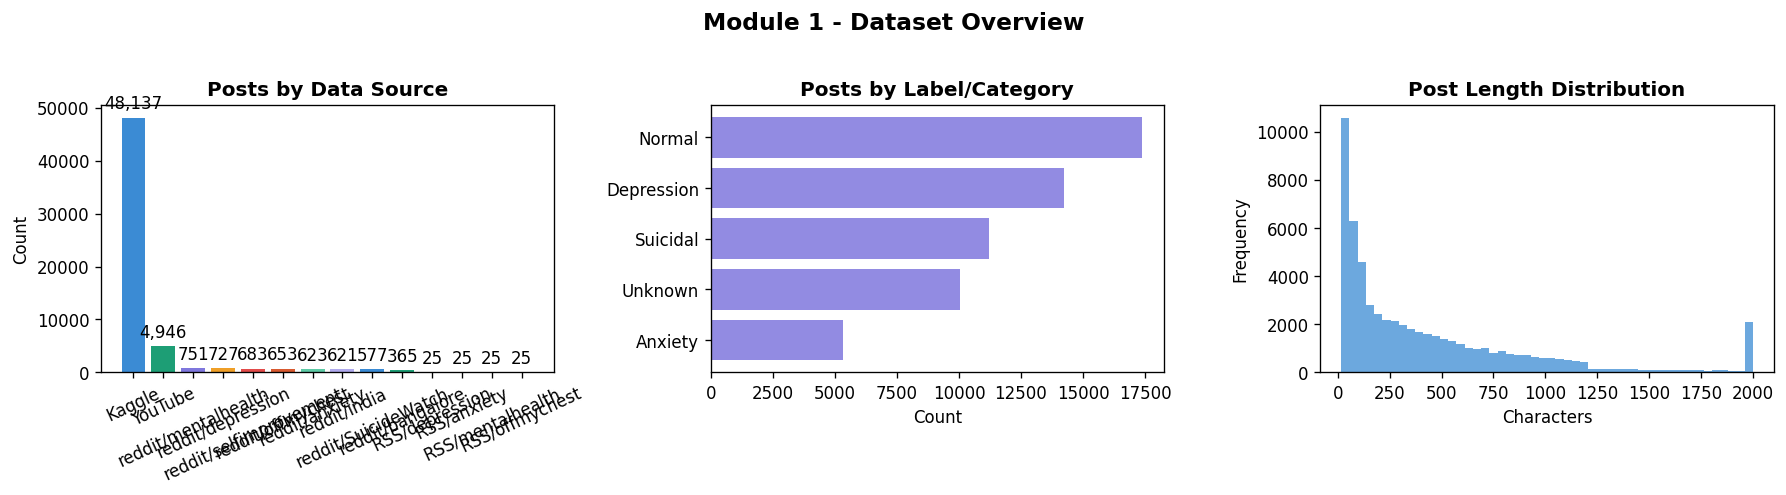

  Saved: outputs/01_dataset_overview.png


In [8]:
# VIZ 1 - Dataset Overview
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sc = df["source"].value_counts()
bars = axes[0].bar(sc.index, sc.values, color=PAL[:len(sc)])
axes[0].bar_label(bars, labels=[f"{v:,}" for v in sc.values], padding=3)
axes[0].set_title("Posts by Data Source", fontweight="bold")
axes[0].set_ylabel("Count"); axes[0].tick_params(axis="x", rotation=25)
lc = df["label"].value_counts().head(10)
axes[1].barh(lc.index[::-1], lc.values[::-1], color="#7F77DD", alpha=0.85)
axes[1].set_title("Posts by Label/Category", fontweight="bold"); axes[1].set_xlabel("Count")
axes[2].hist(df["text_length"].clip(0,2000), bins=50, color="#3B8BD4", alpha=0.75)
axes[2].set_title("Post Length Distribution", fontweight="bold")
axes[2].set_xlabel("Characters"); axes[2].set_ylabel("Frequency")
plt.suptitle("Module 1 - Dataset Overview", fontsize=14, fontweight="bold", y=1.02)
save_show("01_dataset_overview.png")

---
## Module 2 - Text Preprocessing

**Steps:** Lowercase -> URL removal -> Punctuation removal -> Tokenization -> **Stop word removal** -> Lemmatization -> Stemming

In [9]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

NLTK_STOP   = set(stopwords.words("english"))
CUSTOM_STOP = {"im","ive","dont","cant","really","know","going","think","just","also",
               "would","could","like","get","got","want","feel","feeling","one","even",
               "make","nan","deleted","http","www","com","amp","gt","lt"}
ALL_STOP = NLTK_STOP | CUSTOM_STOP
LEM  = WordNetLemmatizer()
STEM = PorterStemmer()

print(f"Stop words: {len(ALL_STOP)} ({len(NLTK_STOP)} NLTK + {len(CUSTOM_STOP)} custom)")

def preprocess(text):
    s = str(text).lower()
    s = re.sub(r"http\S+|www\.\S+", "", s)
    s = re.sub(r"\[deleted\]|\[removed\]", "", s)
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    tokens    = word_tokenize(s)
    no_stop   = [t for t in tokens if t not in ALL_STOP and len(t) > 2]
    lemmatized = [LEM.lemmatize(t) for t in no_stop]
    stemmed    = [STEM.stem(t)     for t in no_stop]
    return {"clean_text": " ".join(lemmatized),
            "tokens":     lemmatized,
            "stems":      stemmed[:8],
            "no_stop":    no_stop[:8],
            "token_count":len(lemmatized)}

print("Preprocessing all texts (2-5 min for large dataset)...")
proc = df["text"].apply(preprocess)
df["clean_text"]  = proc.apply(lambda x: x["clean_text"])
df["tokens"]      = proc.apply(lambda x: x["tokens"])
df["token_count"] = proc.apply(lambda x: x["token_count"])
df = df[df["token_count"] >= 5].reset_index(drop=True)
print(f"Retained {len(df):,} posts")

Stop words: 226 (198 NLTK + 29 custom)
Preprocessing all texts (2-5 min for large dataset)...
Retained 48,335 posts


In [10]:
# Preprocessing walkthrough
print("=" * 60)
print("  PREPROCESSING WALKTHROUGH - Sample Post")
print("=" * 60)
idx = 5; p = proc.iloc[idx]
raw = df["text"].iloc[idx]
print(f"\n  Original   : {raw[:100]}")
print(f"  Step 6 stop: removed {[t for t in word_tokenize(raw.lower()[:100]) if t in ALL_STOP][:6]}")
print(f"  No stop    : {p['no_stop']}")
print(f"  Lemmatized : {p['tokens'][:10]}")
print(f"  Stemmed    : {p['stems']}")
print(f"  Clean text : {p['clean_text'][:100]}")
print("=" * 60)
print("\n-- Cleaned Dataset Preview --")
display(df[["source","label","clean_text","token_count"]].head(5))

  PREPROCESSING WALKTHROUGH - Sample Post

  Original   : Everybody gangsta about mental health til you're outwardly depressed Light depression, light anxiety
  Step 6 stop: removed ['about', 'you']
  No stop    : ['everybody', 'gangsta', 'mental', 'health', 'til', 'outwardly', 'depressed', 'light']
  Lemmatized : ['everybody', 'gangsta', 'mental', 'health', 'til', 'outwardly', 'depressed', 'light', 'depression', 'light']
  Stemmed    : ['everybodi', 'gangsta', 'mental', 'health', 'til', 'outwardli', 'depress', 'light']
  Clean text : everybody gangsta mental health til outwardly depressed light depression light anxiety clinical depr

-- Cleaned Dataset Preview --


,source,label,clean_text,token_count
0,reddit/depression,Unknown,told stressor begin saying inferior slight hea...,150
1,reddit/depression,Unknown,might depressed broke see therapist dunno guy ...,140
2,reddit/mentalhealth,Unknown,aspect workplace working set contributing burn...,45
3,reddit/offmychest,Unknown,recently fallen state appearance anxiety incre...,49
4,reddit/mentalhealth,Unknown,normal thing secretly give anxiety unread mess...,14


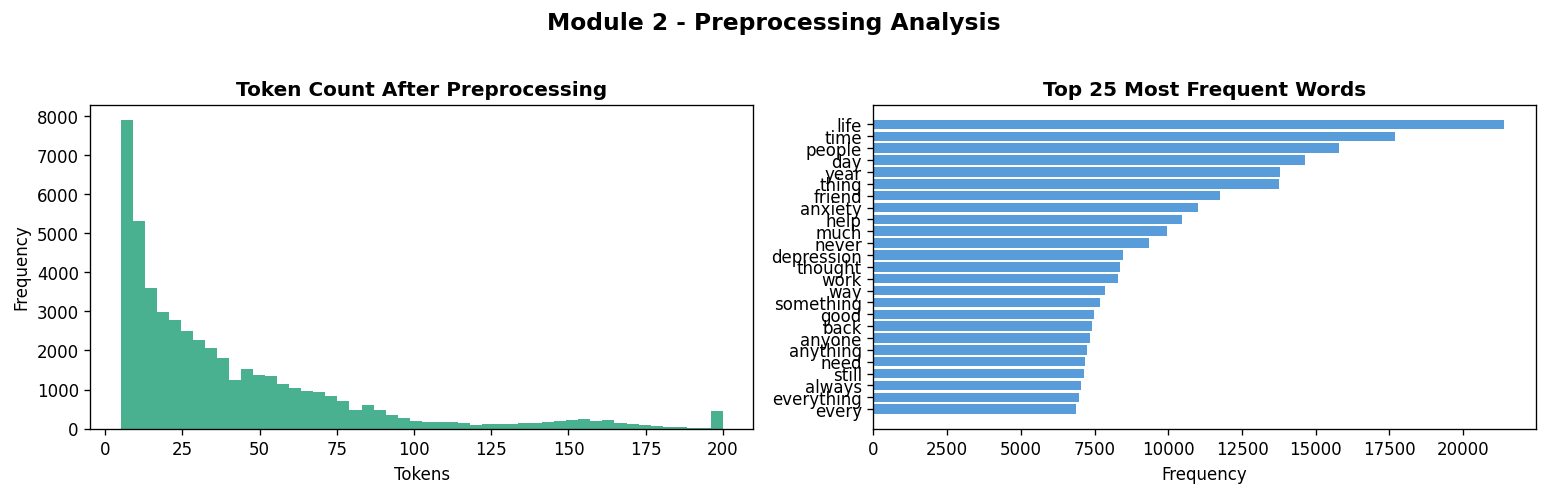

  Saved: outputs/02_preprocessing_analysis.png


In [11]:
# VIZ 2 - Preprocessing + word frequency
all_words = [w for toks in df["tokens"] for w in toks]
wf = Counter(all_words).most_common(25); ws, fs = zip(*wf)
fig, axes = plt.subplots(1,2,figsize=(13,4))
axes[0].hist(df["token_count"].clip(0,200), bins=50, color="#1D9E75", alpha=0.8)
axes[0].set_title("Token Count After Preprocessing", fontweight="bold")
axes[0].set_xlabel("Tokens"); axes[0].set_ylabel("Frequency")
axes[1].barh(list(reversed(ws)), list(reversed(fs)), color="#3B8BD4", alpha=0.85)
axes[1].set_title("Top 25 Most Frequent Words", fontweight="bold"); axes[1].set_xlabel("Frequency")
plt.suptitle("Module 2 - Preprocessing Analysis", fontsize=14, fontweight="bold", y=1.02)
save_show("02_preprocessing_analysis.png")

---
## Module 3 - Text Representation: BoW, TF-IDF, N-grams

In [12]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

corpus = df["clean_text"].tolist()

bow_vec    = CountVectorizer(max_features=5000, min_df=3, max_df=0.95)
bow_matrix = bow_vec.fit_transform(corpus)
bow_vocab  = bow_vec.get_feature_names_out()

tfidf_vec    = TfidfVectorizer(max_features=5000, min_df=3, max_df=0.95, sublinear_tf=True)
tfidf_matrix = tfidf_vec.fit_transform(corpus)
tfidf_vocab  = tfidf_vec.get_feature_names_out()

bi_vec    = CountVectorizer(ngram_range=(2,2), max_features=3000, min_df=3)
bi_matrix = bi_vec.fit_transform(corpus)
bi_vocab  = bi_vec.get_feature_names_out()

tri_vec    = CountVectorizer(ngram_range=(3,3), max_features=2000, min_df=3)
tri_matrix = tri_vec.fit_transform(corpus)
tri_vocab  = tri_vec.get_feature_names_out()

top_bi  = sorted(zip(bi_vocab,  bi_matrix.toarray().sum(0)), key=lambda x:x[1], reverse=True)[:20]
top_tri = sorted(zip(tri_vocab, tri_matrix.toarray().sum(0)), key=lambda x:x[1], reverse=True)[:10]

print(f"BoW matrix   : {bow_matrix.shape}")
print(f"TF-IDF matrix: {tfidf_matrix.shape}")
print(f"Top 10 Bigrams : {[b[0] for b in top_bi[:10]]}")
print(f"Top 10 Trigrams: {[t[0] for t in top_tri[:10]]}")

print("\nTop TF-IDF terms per label:")
lbl_tfidf_rows = []
for lbl in df["label"].value_counts().head(6).index:
    sub = " ".join(df[df["label"]==lbl]["clean_text"].tolist())
    if len(sub.strip()) < 10: continue
    v = TfidfVectorizer(max_features=2000, min_df=1)
    m = v.fit_transform([sub])
    top = sorted(zip(v.get_feature_names_out(), m.toarray()[0]), key=lambda x:x[1], reverse=True)[:8]
    lbl_tfidf_rows.append({"Label":lbl, "Top TF-IDF Terms":", ".join([w for w,_ in top])})
    print(f"  {lbl:<16}: {[w for w,_ in top]}")
display(pd.DataFrame(lbl_tfidf_rows))

BoW matrix   : (48335, 5000)
TF-IDF matrix: (48335, 5000)
Top 10 Bigrams : ['link comment', 'mom mom', 'mental health', 'panic attack', 'head head', 'anyone else', 'year old', 'every day', 'year ago', 'hate life']
Top 10 Trigrams: ['hate life hate', 'life hate life', 'filler filler filler', 'fuck fuck fuck', 'every single day', 'mental health issue', 'hate hate hate', 'long story short', 'need someone talk', 'anxiety panic attack']

Top TF-IDF terms per label:
  Depression      : ['life', 'time', 'people', 'depression', 'day', 'thing', 'friend', 'year']
  Suicidal        : ['life', 'time', 'people', 'year', 'thing', 'friend', 'day', 'die']
  Normal          : ['mom', 'time', 'day', 'people', 'friend', 'year', 'filler', 'good']
  Unknown         : ['life', 'time', 'comment', 'year', 'link', 'people', 'submitted', 'thing']
  Anxiety         : ['anxiety', 'time', 'day', 'thing', 'people', 'year', 'something', 'anyone']


,Label,Top TF-IDF Terms
0,Depression,"life, time, people, depression, day, thing, fr..."
1,Suicidal,"life, time, people, year, thing, friend, day, die"
2,Normal,"mom, time, day, people, friend, year, filler, ..."
3,Unknown,"life, time, comment, year, link, people, submi..."
4,Anxiety,"anxiety, time, day, thing, people, year, somet..."


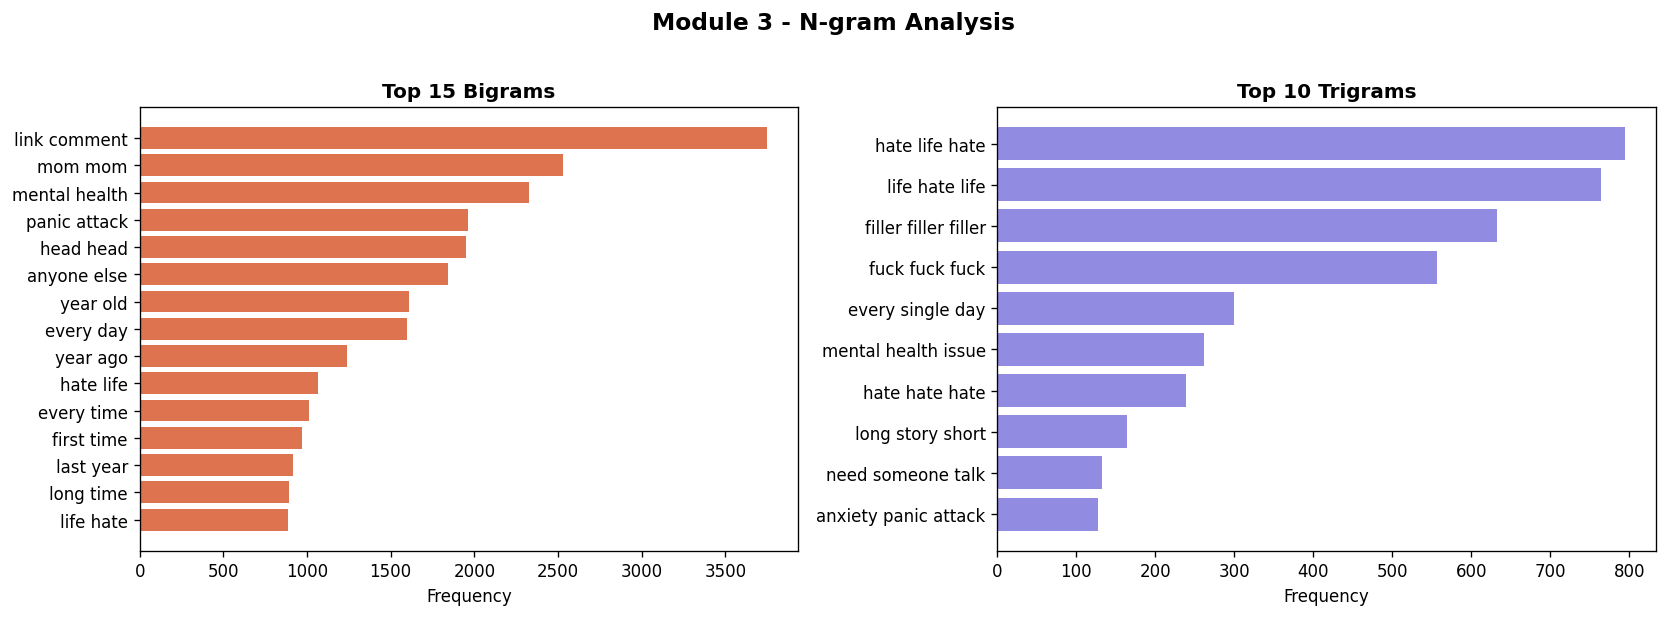

  Saved: outputs/03_ngrams.png


In [13]:
# VIZ 3 - N-grams
fig, axes = plt.subplots(1,2,figsize=(14,5))
bg_w, bg_c = zip(*top_bi[:15])
axes[0].barh(list(reversed(bg_w)), list(reversed(bg_c)), color="#D85A30", alpha=0.85)
axes[0].set_title("Top 15 Bigrams", fontweight="bold"); axes[0].set_xlabel("Frequency")
tg_w, tg_c = zip(*top_tri[:10])
axes[1].barh(list(reversed(tg_w)), list(reversed(tg_c)), color="#7F77DD", alpha=0.85)
axes[1].set_title("Top 10 Trigrams", fontweight="bold"); axes[1].set_xlabel("Frequency")
plt.suptitle("Module 3 - N-gram Analysis", fontsize=14, fontweight="bold", y=1.02)
save_show("03_ngrams.png")

---
## Module 4 - Word Embeddings: Word2Vec (Skip-gram)

In [14]:
from gensim.models import Word2Vec

w2v = Word2Vec(sentences=df["tokens"].tolist(),
               vector_size=100, window=5, min_count=5,
               sg=1, workers=4, epochs=15)
print(f"Word2Vec | Vocab: {len(w2v.wv):,} | 100-dim | Skip-gram")
sim_rows = []
for word in ["suicide","depression","anxiety","help","therapy","alone"]:
    if word in w2v.wv:
        similar = w2v.wv.most_similar(word, topn=6)
        sim_rows.append({"Word":word,
                          "Top Similar Words":", ".join([w for w,_ in similar]),
                          "Best Score":round(similar[0][1],4)})
        print(f"  '{word}' -> {[w for w,_ in similar]}")
display(pd.DataFrame(sim_rows))
w2v.save("outputs/word2vec.model")

Word2Vec | Vocab: 13,183 | 100-dim | Skip-gram
  'suicide' -> ['killing', 'sui', 'sucide', 'suicidal', 'commit', 'scaredi']
  'depression' -> ['bipolar', 'inattentive', 'mdd', 'depressive', 'bdd', 'recurrent']
  'anxiety' -> ['bdd', 'generalised', 'emetophobia', 'hindered', 'cardiophobia', 'panic']
  'help' -> ['advice', 'profesional', 'suicidial', 'utilize', 'support', 'helpi']
  'therapy' -> ['cbt', 'therapist', 'counseling', 'dbt', 'medication', 'session']
  'alone' -> ['lonely', 'pathethic', 'unlivable', 'painfull', 'miserable', 'tbf']


,Word,Top Similar Words,Best Score
0,suicide,"killing, sui, sucide, suicidal, commit, scaredi",0.7145
1,depression,"bipolar, inattentive, mdd, depressive, bdd, re...",0.6503
2,anxiety,"bdd, generalised, emetophobia, hindered, cardi...",0.6983
3,help,"advice, profesional, suicidial, utilize, suppo...",0.6787
4,therapy,"cbt, therapist, counseling, dbt, medication, s...",0.8003
5,alone,"lonely, pathethic, unlivable, painfull, misera...",0.6904


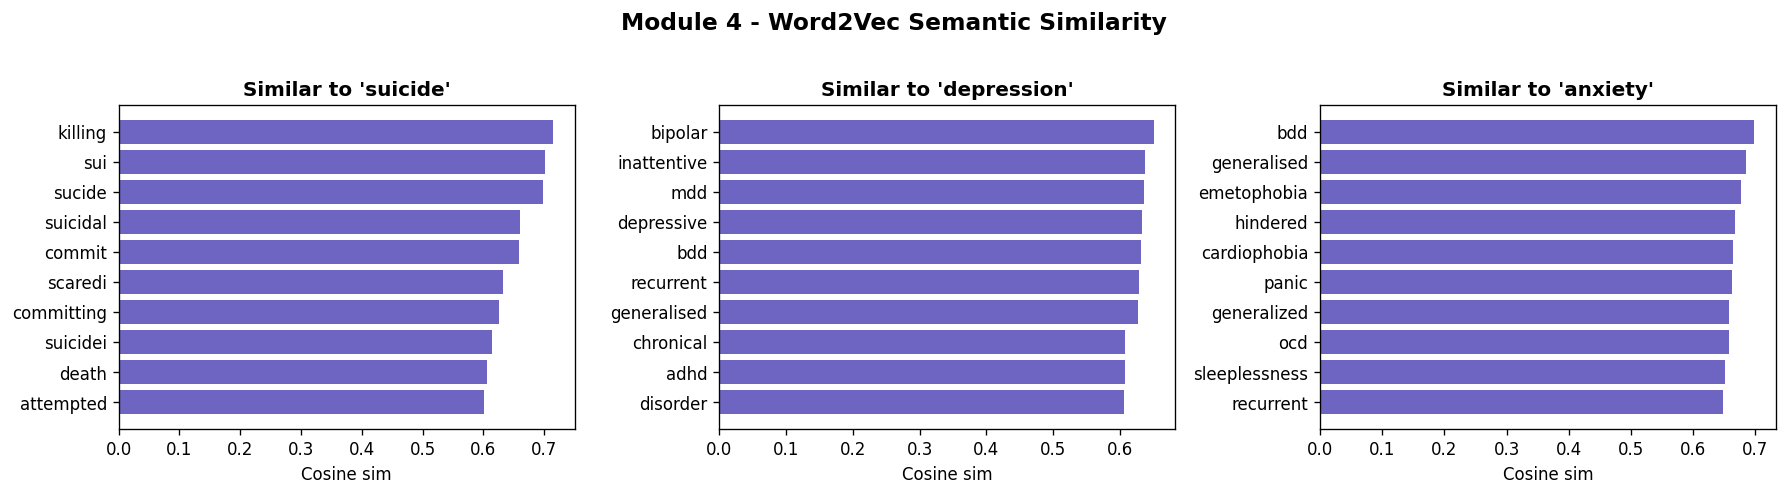

  Saved: outputs/04_word2vec.png


In [15]:
# VIZ 4 - Word2Vec
fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax, word in zip(axes, ["suicide","depression","anxiety"]):
    if word not in w2v.wv: ax.set_visible(False); continue
    sim = w2v.wv.most_similar(word, topn=10); ws2, ss = zip(*sim)
    ax.barh(list(reversed(ws2)), list(reversed(ss)), color="#534AB7", alpha=0.85)
    ax.set_title(f"Similar to '{word}'", fontweight="bold"); ax.set_xlabel("Cosine sim")
plt.suptitle("Module 4 - Word2Vec Semantic Similarity", fontsize=14, fontweight="bold", y=1.02)
save_show("04_word2vec.png")

---
## Module 5 - Sentiment Analysis
### 5A: VADER (Rule-Based)
### 5B: ML Classifiers (Naive Bayes, SVM, Logistic Regression)

In [17]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

vader = SentimentIntensityAnalyzer()
def get_sentiment(t):
    c = vader.polarity_scores(str(t))["compound"]
    return "Positive" if c>=0.05 else ("Negative" if c<=-0.05 else "Neutral")
def get_compound(t):
    return round(vader.polarity_scores(str(t))["compound"],4)

print("Running VADER...")
df["sentiment"]      = df["text"].apply(get_sentiment)
df["vader_compound"] = df["text"].apply(get_compound)
print(df["sentiment"].value_counts().to_string())
print(f"Mean compound: {df['vader_compound'].mean():.4f}")

print("\n-- Sentiment by Source --")
display(pd.crosstab(df["source"], df["sentiment"], normalize="index").mul(100).round(1))

print("\n-- Sentiment by Label --")
labeled_tmp = df[df["label"]!="Unknown"]
if len(labeled_tmp)>0:
    display(pd.crosstab(labeled_tmp["label"], labeled_tmp["sentiment"], normalize="index").mul(100).round(1))

Running VADER...
sentiment
Negative    27826
Positive    17857
Neutral      2652
Mean compound: -0.1869

-- Sentiment by Source --


sentiment,Negative,Neutral,Positive
source,,,
Kaggle,58.5,5.8,35.7
RSS/anxiety,70.8,0.0,29.2
RSS/depression,40.0,8.0,52.0
RSS/mentalhealth,52.0,0.0,48.0
RSS/offmychest,48.0,4.0,48.0
YouTube,41.8,7.5,50.7
reddit/SuicideWatch,79.7,1.9,18.4
reddit/anxiety,67.1,1.6,31.3
reddit/bangalore,36.2,2.7,61.1



-- Sentiment by Label --


sentiment,Negative,Neutral,Positive
label,,,
Anxiety,62.1,1.5,36.3
Depression,66.1,2.1,31.8
Normal,32.1,16.0,51.9
Suicidal,72.5,2.7,24.8


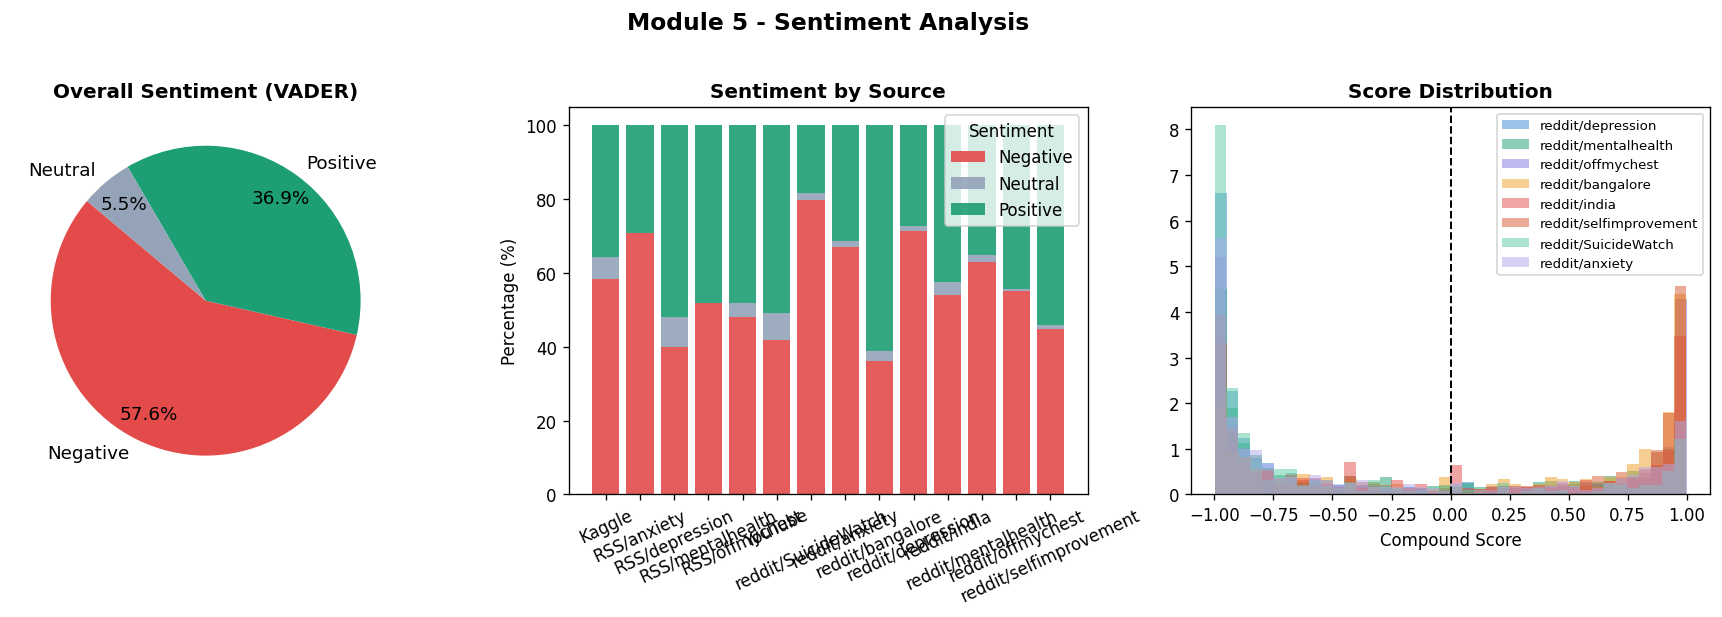

  Saved: outputs/05_sentiment.png


In [18]:
# VIZ 5 - Sentiment
fig, axes = plt.subplots(1,3,figsize=(15,5))
sc2 = df["sentiment"].value_counts()
axes[0].pie(sc2.values, labels=sc2.index, autopct="%1.1f%%",
            colors=[SC.get(s,"#888") for s in sc2.index],
            startangle=140, textprops={"fontsize":11}, pctdistance=0.82)
axes[0].set_title("Overall Sentiment (VADER)", fontweight="bold")
sb = df.groupby(["source","sentiment"]).size().unstack(fill_value=0)
sb_pct = sb.div(sb.sum(1),axis=0)*100
bot = np.zeros(len(sb_pct))
for s in ["Negative","Neutral","Positive"]:
    if s in sb_pct.columns:
        axes[1].bar(sb_pct.index, sb_pct[s], bottom=bot, label=s, color=SC[s], alpha=0.9)
        bot += sb_pct[s].values
axes[1].set_title("Sentiment by Source", fontweight="bold"); axes[1].set_ylabel("Percentage (%)")
axes[1].legend(title="Sentiment"); axes[1].tick_params(axis="x",rotation=25)
for src, col in zip(df["source"].unique(), PAL):
    axes[2].hist(df[df["source"]==src]["vader_compound"].values,
                  bins=40, alpha=0.5, label=src, color=col, density=True)
axes[2].axvline(0,color="black",linestyle="--",linewidth=1.2)
axes[2].set_xlabel("Compound Score"); axes[2].set_title("Score Distribution", fontweight="bold")
axes[2].legend(fontsize=8)
plt.suptitle("Module 5 - Sentiment Analysis", fontsize=14, fontweight="bold", y=1.02)
save_show("05_sentiment.png")

In [19]:
# ML Sentiment Classifiers
le_sent = LabelEncoder(); y_sent = le_sent.fit_transform(df["sentiment"])
Xtr,Xte,ytr,yte = train_test_split(tfidf_matrix,y_sent,test_size=0.2,random_state=42,stratify=y_sent)
sent_results = {}
for name, clf in [("Naive Bayes",MultinomialNB(alpha=0.1)),
                  ("SVM",LinearSVC(C=1.0,max_iter=3000,random_state=42)),
                  ("Logistic Regression",LogisticRegression(C=1.0,max_iter=500,random_state=42))]:
    clf.fit(Xtr,ytr); pred = clf.predict(Xte); acc = accuracy_score(yte,pred)
    sent_results[name] = acc
    print(f"\n{name} -> Accuracy: {acc:.4f}")
    print(classification_report(yte,pred,target_names=le_sent.classes_,digits=4))


Naive Bayes -> Accuracy: 0.7218
              precision    recall  f1-score   support

    Negative     0.7092    0.9265    0.8034      5565
     Neutral     0.4286    0.0282    0.0530       531
    Positive     0.7650    0.5060    0.6091      3571

    accuracy                         0.7218      9667
   macro avg     0.6343    0.4869    0.4885      9667
weighted avg     0.7144    0.7218    0.6904      9667


SVM -> Accuracy: 0.7982
              precision    recall  f1-score   support

    Negative     0.8325    0.8742    0.8528      5565
     Neutral     0.5500    0.2279    0.3222       531
    Positive     0.7577    0.7645    0.7611      3571

    accuracy                         0.7982      9667
   macro avg     0.7134    0.6222    0.6454      9667
weighted avg     0.7893    0.7982    0.7898      9667


Logistic Regression -> Accuracy: 0.8053
              precision    recall  f1-score   support

    Negative     0.8303    0.8898    0.8591      5565
     Neutral     0.6447    0.1

---
## Module 6 - Text Classification

**Kaggle labels used:** Suicidal, Depression, Anxiety, Normal, Bipolar, Stress, etc.

**Data leakage fix applied:** TF-IDF fitted ONLY on training split.

In [20]:
from sklearn.metrics import confusion_matrix

# Use Kaggle labeled data (status column values)
labeled = df[df["source"]=="Kaggle"].copy()
if len(labeled) < 200:
    labeled = df[df["label"]!="Unknown"].copy()

print(f"Labeled posts: {len(labeled):,}")
print("\nLabel distribution:")
lc2 = labeled["label"].value_counts()
display(lc2.reset_index().rename(columns={"index":"Label","label":"Count"}))

min_samples = 50
keep = lc2[lc2>=min_samples].index
labeled = labeled[labeled["label"].isin(keep)].copy()
print(f"\nKept {len(labeled):,} posts with {len(keep)} labels")

le2 = LabelEncoder(); y2 = le2.fit_transform(labeled["label"])
print(f"Classes: {list(le2.classes_)}")

Xtr2, Xte2, ytr2, yte2 = train_test_split(
    labeled["clean_text"], y2, test_size=0.2, random_state=42, stratify=y2)

# FIX: Vectorizer fitted ONLY on training data
tv2 = TfidfVectorizer(max_features=5000, min_df=2, sublinear_tf=True)
X_train2 = tv2.fit_transform(Xtr2)   # fit on train only
X_test2  = tv2.transform(Xte2)       # transform test separately

cat_results = {}; best_cm, best_name = None, ""
for name, clf in [("Naive Bayes",MultinomialNB(alpha=0.3)),
                  ("SVM",LinearSVC(C=1.0,max_iter=3000,random_state=42)),
                  ("Logistic Regression",LogisticRegression(C=1.0,max_iter=500,random_state=42))]:
    clf.fit(X_train2,ytr2); pred = clf.predict(X_test2); acc = accuracy_score(yte2,pred)
    cm = confusion_matrix(yte2,pred); cat_results[name] = {"acc":acc,"cm":cm}
    if best_cm is None or acc > cat_results.get(best_name,{}).get("acc",0): best_cm,best_name=cm,name
    print(f"\n{name} -> Accuracy: {acc:.4f}")
    print(classification_report(yte2,pred,target_names=le2.classes_,digits=4))

Labeled posts: 40,124

Label distribution:


,Count,count
0,Depression,13939
1,Suicidal,10757
2,Normal,10412
3,Anxiety,5016



Kept 40,124 posts with 4 labels
Classes: ['Anxiety', 'Depression', 'Normal', 'Suicidal']

Naive Bayes -> Accuracy: 0.6464
              precision    recall  f1-score   support

     Anxiety     0.7868    0.5005    0.6118      1003
  Depression     0.5404    0.7310    0.6214      2788
      Normal     0.8166    0.6907    0.7484      2082
    Suicidal     0.6518    0.5618    0.6034      2152

    accuracy                         0.6464      8025
   macro avg     0.6989    0.6210    0.6463      8025
weighted avg     0.6727    0.6464    0.6483      8025


SVM -> Accuracy: 0.7115
              precision    recall  f1-score   support

     Anxiety     0.7627    0.7308    0.7464      1003
  Depression     0.6771    0.6259    0.6505      2788
      Normal     0.7961    0.8890    0.8400      2082
    Suicidal     0.6388    0.6417    0.6402      2152

    accuracy                         0.7115      8025
   macro avg     0.7187    0.7219    0.7193      8025
weighted avg     0.7084    0.7115    

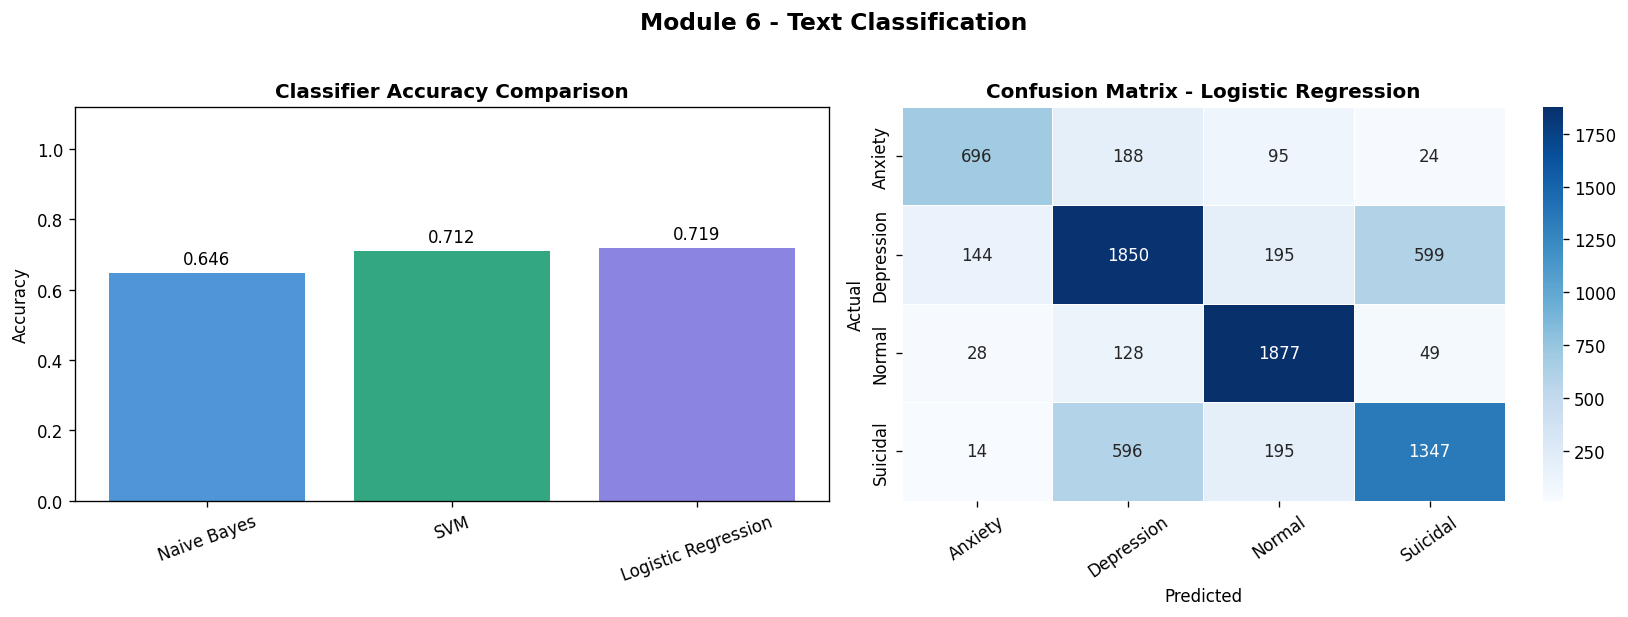

  Saved: outputs/06_classification.png


In [21]:
# VIZ 6 - Classification
fig, axes = plt.subplots(1,2,figsize=(14,5))
all_accs = {**sent_results,**{k:v["acc"] for k,v in cat_results.items()}}
ns = list(all_accs.keys()); vs = list(all_accs.values())
bars = axes[0].bar(ns, vs, color=PAL[:len(ns)], alpha=0.9)
axes[0].bar_label(bars, labels=[f"{a:.3f}" for a in vs], padding=3)
axes[0].set_ylim(0,1.12); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Classifier Accuracy Comparison", fontweight="bold")
axes[0].tick_params(axis="x", rotation=20)
sns.heatmap(best_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le2.classes_, yticklabels=le2.classes_, ax=axes[1], linewidths=0.5)
axes[1].set_title(f"Confusion Matrix - {best_name}", fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].tick_params(axis="x", rotation=35)
plt.suptitle("Module 6 - Text Classification", fontsize=14, fontweight="bold", y=1.02)
save_show("06_classification.png")

---
## Module 7 - Topic Modeling: LDA + LSA



In [22]:
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD

N_TOPICS = 10
lda = LatentDirichletAllocation(n_components=N_TOPICS,random_state=42,max_iter=25,learning_method="online")
lda_matrix = lda.fit_transform(bow_matrix)
df["lda_topic"] = lda_matrix.argmax(axis=1)

TOPIC_INTERPRETATIONS = {
    0:"Academic & Student Stress",    1:"Emotional Loneliness & Isolation",
    2:"Suicidal Ideation & Crisis",   3:"Therapy & Professional Help",
    4:"Medication & Treatment",       5:"Family & Relationship Conflict",
    6:"Sleep Disorders & Symptoms",   7:"Hope, Recovery & Coping",
    8:"Anxiety & Panic Attacks",      9:"Daily Life & General Depression",
}

lda_keyword_map = {}; topic_rows = []
print("LDA Topics with Interpretations:\n")
for i, top in enumerate(lda.components_):
    words = [bow_vocab[j] for j in top.argsort()[-12:][::-1]]
    lda_keyword_map[i] = words[:3]
    interp = TOPIC_INTERPRETATIONS.get(i,f"Topic {i+1}")
    count  = (df["lda_topic"]==i).sum()
    topic_rows.append({"Topic #":i+1,"Interpretation":interp,
                        "Top Keywords":", ".join(words[:8]),"Post Count":count})
    print(f"  T{i+1:2d} [{interp}]: {', '.join(words[:8])}")

topic_df = pd.DataFrame(topic_rows)
display(topic_df)

lsa = TruncatedSVD(n_components=N_TOPICS,random_state=42)
lsa_matrix = lsa.fit_transform(tfidf_matrix)
df["lsa_topic"] = lsa_matrix.argmax(axis=1)
print("\nLSA computed.")

LDA Topics with Interpretations:

  T 1 [Academic & Student Stress]: anxiety, head, attack, panic, pain, anxious, anyone, heart
  T 2 [Emotional Loneliness & Isolation]: time, day, life, thing, year, work, better, much
  T 3 [Suicidal Ideation & Crisis]: mom, school, year, parent, college, dad, class, kid
  T 4 [Therapy & Professional Help]: job, work, money, pay, filler, working, new, afford
  T 5 [Medication & Treatment]: people, comment, link, submitted, mental, health, thing, depression
  T 6 [Family & Relationship Conflict]: life, people, hate, fucking, die, anymore, kill, fuck
  T 7 [Sleep Disorders & Symptoms]: help, need, please, someone, talk, depression, therapist, anyone
  T 8 [Hope, Recovery & Coping]: friend, time, year, never, talk, told, girl, said
  T 9 [Anxiety & Panic Attacks]: today, back, day, went, hour, phone, home, said
  T10 [Daily Life & General Depression]: sleep, depression, day, dream, night, brain, mind, body


,Topic #,Interpretation,Top Keywords,Post Count
0,1,Academic & Student Stress,"anxiety, head, attack, panic, pain, anxious, a...",3498
1,2,Emotional Loneliness & Isolation,"time, day, life, thing, year, work, better, much",13852
2,3,Suicidal Ideation & Crisis,"mom, school, year, parent, college, dad, class...",1275
3,4,Therapy & Professional Help,"job, work, money, pay, filler, working, new, a...",525
4,5,Medication & Treatment,"people, comment, link, submitted, mental, heal...",5381
5,6,Family & Relationship Conflict,"life, people, hate, fucking, die, anymore, kil...",11670
6,7,Sleep Disorders & Symptoms,"help, need, please, someone, talk, depression,...",1718
7,8,"Hope, Recovery & Coping","friend, time, year, never, talk, told, girl, said",5447
8,9,Anxiety & Panic Attacks,"today, back, day, went, hour, phone, home, said",3594
9,10,Daily Life & General Depression,"sleep, depression, day, dream, night, brain, m...",1375



LSA computed.


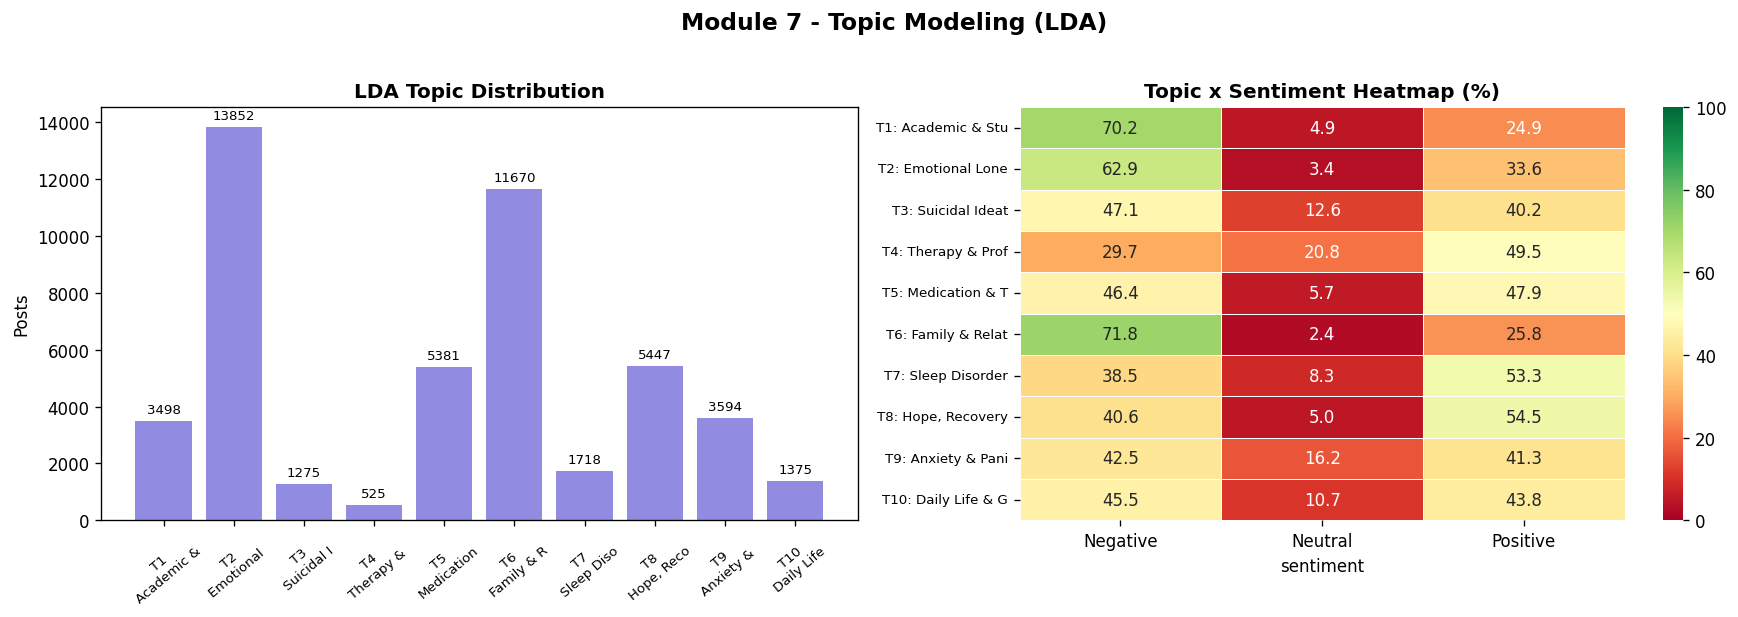

  Saved: outputs/07_topic_modeling.png


In [23]:
# VIZ 7 - Topic Modeling
fig, axes = plt.subplots(1,2,figsize=(15,5))
tc   = df["lda_topic"].value_counts().sort_index()
lbls = [f"T{i+1}\n{TOPIC_INTERPRETATIONS.get(i,'')[:10]}" for i in tc.index]
bars = axes[0].bar(lbls, tc.values, color="#7F77DD", alpha=0.85)
axes[0].bar_label(bars, padding=3, fontsize=8)
axes[0].set_ylabel("Posts"); axes[0].set_title("LDA Topic Distribution", fontweight="bold")
axes[0].tick_params(axis="x", rotation=40, labelsize=8)
ts = pd.crosstab(df["lda_topic"],df["sentiment"],normalize="index")*100
ts.index = [f"T{i+1}: {TOPIC_INTERPRETATIONS.get(i,'')[:14]}" for i in ts.index]
sns.heatmap(ts,annot=True,fmt=".1f",cmap="RdYlGn",linewidths=0.5,ax=axes[1],vmin=0,vmax=100)
axes[1].set_title("Topic x Sentiment Heatmap (%)", fontweight="bold")
axes[1].tick_params(axis="y",labelsize=8)
plt.suptitle("Module 7 - Topic Modeling (LDA)", fontsize=14, fontweight="bold", y=1.02)
save_show("07_topic_modeling.png")

---
## Module 8 - Document Clustering: K-Means + Hierarchical

Each cluster is given an interpretation based on representative words.

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage

K = 5
km = KMeans(n_clusters=K,random_state=42,n_init=10)
km.fit(tfidf_matrix)
df["cluster"] = km.labels_
sil = silhouette_score(tfidf_matrix,km.labels_,sample_size=3000,random_state=42)
print(f"K-Means Silhouette Score: {sil:.4f}  (>0.2 = reasonable)")

CLUSTER_INTERP = {
    0:"Anxiety & Panic",       1:"Depression & Low Mood",
    2:"Suicidal Thoughts",     3:"Recovery & Therapy",
    4:"Family & Relationships"
}
cluster_rows = []; order = km.cluster_centers_.argsort()[:,::-1]
for i in range(K):
    terms  = [tfidf_vocab[j] for j in order[i,:10]]
    interp = CLUSTER_INTERP.get(i,f"Cluster {i}")
    cnt    = (df["cluster"]==i).sum()
    cluster_rows.append({"Cluster":i,"Interpretation":interp,
                          "Top Terms":", ".join(terms[:7]),
                          "Posts":cnt,"Pct":f"{cnt/len(df)*100:.1f}%"})
    print(f"  C{i} [{interp}] - {cnt:,} posts: {', '.join(terms[:7])}")

display(pd.DataFrame(cluster_rows))

samp_n   = min(500,len(df)); samp_idx = np.random.choice(len(df),samp_n,replace=False)
samp_mat = tfidf_matrix[samp_idx].toarray()
samp_src = df["source"].iloc[samp_idx].tolist()
Z = linkage(samp_mat,method="ward")
print("Hierarchical linkage computed.")

K-Means Silhouette Score: 0.0025  (>0.2 = reasonable)
  C0 [Anxiety & Panic] - 12,506 posts: time, year, day, anxiety, thing, friend, life
  C1 [Depression & Low Mood] - 19,894 posts: day, people, help, anyone, need, good, time
  C2 [Suicidal Thoughts] - 3,055 posts: depression, anxiety, people, help, depressed, life, thing
  C3 [Recovery & Therapy] - 10,106 posts: life, anymore, die, people, hate, fucking, kill
  C4 [Family & Relationships] - 2,774 posts: comment, link, submitted, anxiety, mental, health, life


,Cluster,Interpretation,Top Terms,Posts,Pct
0,0,Anxiety & Panic,"time, year, day, anxiety, thing, friend, life",12506,25.9%
1,1,Depression & Low Mood,"day, people, help, anyone, need, good, time",19894,41.2%
2,2,Suicidal Thoughts,"depression, anxiety, people, help, depressed, ...",3055,6.3%
3,3,Recovery & Therapy,"life, anymore, die, people, hate, fucking, kill",10106,20.9%
4,4,Family & Relationships,"comment, link, submitted, anxiety, mental, hea...",2774,5.7%


Hierarchical linkage computed.


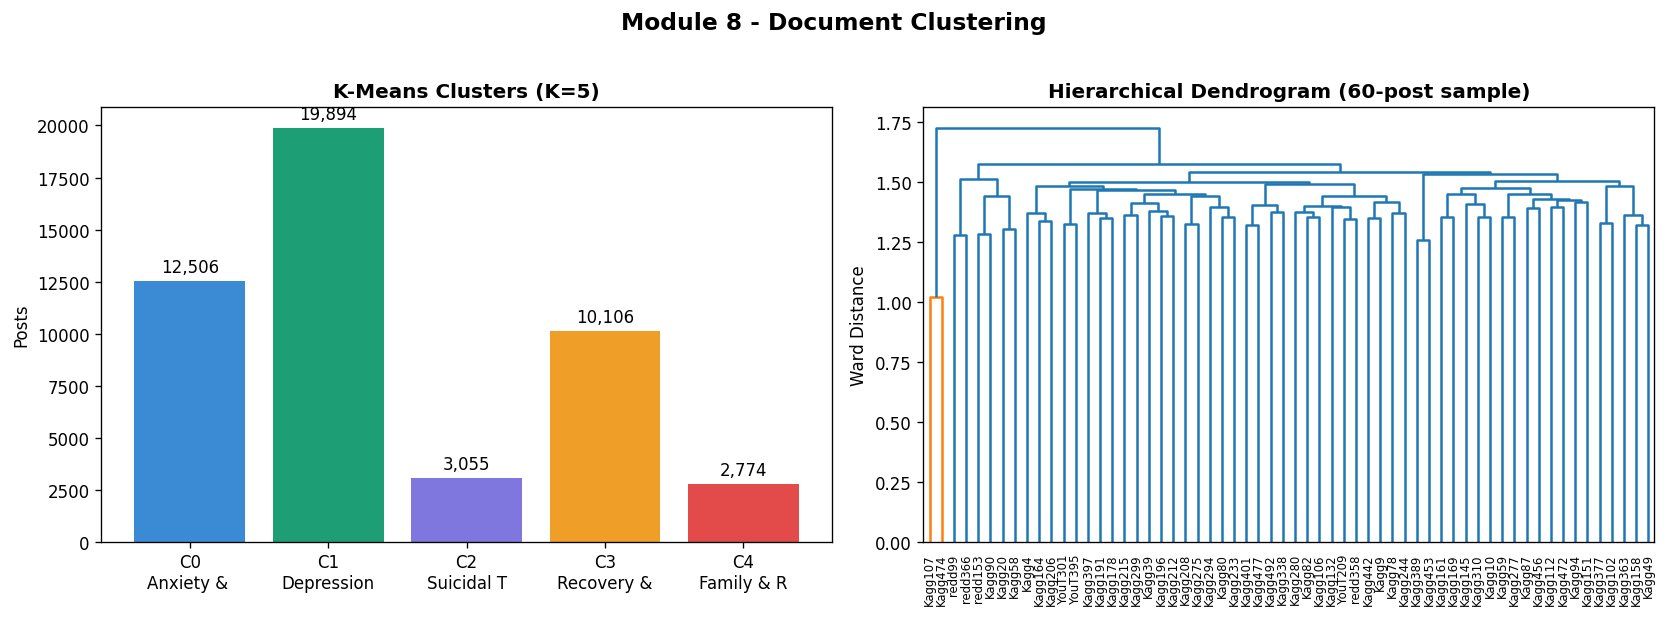

  Saved: outputs/08_clustering.png


In [26]:
# VIZ 8 - Clustering
from scipy.cluster.hierarchy import dendrogram as spy_dend
fig, axes = plt.subplots(1,2,figsize=(14,5))
cc = df["cluster"].value_counts().sort_index()
clbl = [f"C{i}\n{CLUSTER_INTERP.get(i,'')[:10]}" for i in cc.index]

# FIX: Capture the container returned by .bar() to use in bar_label
bars = axes[0].bar(clbl, cc.values, color=PAL[:K])
axes[0].bar_label(bars, labels=[f"{v:,}" for v in cc.values], padding=3)

axes[0].set_ylabel("Posts"); axes[0].set_title(f"K-Means Clusters (K={K})", fontweight="bold")
tiny_n   = 60; tiny_idx = np.random.choice(len(samp_mat),tiny_n,replace=False)
Ztiny    = linkage(samp_mat[tiny_idx],method="ward")
tlbls    = [samp_src[i][:4]+str(i) for i in tiny_idx]
spy_dend(Ztiny,labels=tlbls,ax=axes[1],leaf_rotation=90,leaf_font_size=7,
          color_threshold=0.65*max(Ztiny[:,2]))
axes[1].set_title("Hierarchical Dendrogram (60-post sample)", fontweight="bold")
axes[1].set_ylabel("Ward Distance")
plt.suptitle("Module 8 - Document Clustering", fontsize=14, fontweight="bold", y=1.02)
save_show("08_clustering.png")

---
## Module 9 - Named Entity Recognition (spaCy)



In [27]:
import spacy
nlp_ner = spacy.load("en_core_web_sm",
                      disable=["tok2vec","tagger","parser","attribute_ruler","lemmatizer"])
NER_N = min(800,len(df))
print(f"Running NER on {NER_N} posts...")
ner_records = []
for txt in df["text"].sample(NER_N,random_state=42):
    doc = nlp_ner(str(txt)[:500])
    for ent in doc.ents:
        if ent.label_ in ("PERSON","ORG","GPE","LOC","PRODUCT","EVENT","NORP"):
            ner_records.append({"Entity Text":ent.text.strip(),
                                  "Entity Type":ent.label_,
                                  "Type Meaning":spacy.explain(ent.label_) or ent.label_})
ner_df = pd.DataFrame(ner_records)
print(f"Total entities found: {len(ner_df):,}")

Running NER on 800 posts...
Total entities found: 316


In [28]:
# Display entities in  Entity: "text" -> TYPE  format
if not ner_df.empty:
    print("\n-- Entity Type Summary --")
    etype_sum = ner_df.groupby("Entity Type").agg(
        Count=("Entity Text","count"),
        Meaning=("Type Meaning","first"),
        Top_Entities=("Entity Text",lambda x:", ".join(x.value_counts().head(5).index.tolist()))
    ).reset_index()
    display(etype_sum)

    print("\n-- Top 20 Entities (Entity: text -> TYPE format) --")
    top_ents = ner_df["Entity Text"].value_counts().head(20)
    ner_disp = []
    for ent_text, cnt in top_ents.items():
        ent_type = ner_df[ner_df["Entity Text"]==ent_text]["Entity Type"].mode()[0]
        meaning  = spacy.explain(ent_type) or ent_type
        ner_disp.append({"Entity":f'"{ent_text}"',"Type":ent_type,"Meaning":meaning,"Count":cnt})
        print(f'  Entity: "{ent_text}" -> {ent_type} ({meaning})')
    display(pd.DataFrame(ner_disp))

    print("\n-- Top GPE (Countries/Cities) --")
    display(ner_df[ner_df["Entity Type"]=="GPE"]["Entity Text"].value_counts().head(12).reset_index())
    print("\n-- Top ORG (Organisations) --")
    display(ner_df[ner_df["Entity Type"]=="ORG"]["Entity Text"].value_counts().head(12).reset_index())

    ner_df.to_excel("outputs/ner_results.xlsx",index=False)
    etype_sum.to_excel("outputs/ner_summary.xlsx",index=False)
    print("\nNER results saved to Excel!")


-- Entity Type Summary --


,Entity Type,Count,Meaning,Top_Entities
0,GPE,68,"Countries, cities, states","UK, Spotify, Ill, US, England"
1,LOC,2,"Non-GPE locations, mountain ranges, bodies of ...","Lonely Island, NYC"
2,NORP,26,Nationalities or religious or political groups,"indians, Indian, Shia, indian, muslim"
3,ORG,109,"Companies, agencies, institutions, etc.","BPD, ER, doc, Walmart, NNN"
4,PERSON,102,"People, including fictional","don, Idk, ¦, Ill, doesn"
5,PRODUCT,9,"Objects, vehicles, foods, etc. (not services)","CA, the X-Ray, USD, Damn, Alister"



-- Top 20 Entities (Entity: text -> TYPE format) --
  Entity: "Ill" -> PERSON (People, including fictional)
  Entity: "don" -> PERSON (People, including fictional)
  Entity: "¦" -> PERSON (People, including fictional)
  Entity: "Indian" -> NORP (Nationalities or religious or political groups)
  Entity: "Idk" -> PERSON (People, including fictional)
  Entity: "BPD" -> ORG (Companies, agencies, institutions, etc.)
  Entity: "indians" -> NORP (Nationalities or religious or political groups)
  Entity: "doesn" -> PERSON (People, including fictional)
  Entity: "US" -> GPE (Countries, cities, states)
  Entity: "ER" -> ORG (Companies, agencies, institutions, etc.)
  Entity: "UK" -> GPE (Countries, cities, states)
  Entity: "Spotify" -> GPE (Countries, cities, states)
  Entity: "doc" -> ORG (Companies, agencies, institutions, etc.)
  Entity: "Suicide" -> GPE (Countries, cities, states)
  Entity: "Animo" -> PERSON (People, including fictional)
  Entity: "indian" -> NORP (Nationalities or religio

,Entity,Type,Meaning,Count
0,"""Ill""",PERSON,"People, including fictional",7
1,"""don""",PERSON,"People, including fictional",6
2,"""¦""",PERSON,"People, including fictional",4
3,"""Indian""",NORP,Nationalities or religious or political groups,4
4,"""Idk""",PERSON,"People, including fictional",4
5,"""BPD""",ORG,"Companies, agencies, institutions, etc.",4
6,"""indians""",NORP,Nationalities or religious or political groups,4
7,"""doesn""",PERSON,"People, including fictional",3
8,"""US""",GPE,"Countries, cities, states",3
9,"""ER""",ORG,"Companies, agencies, institutions, etc.",3



-- Top GPE (Countries/Cities) --


,Entity Text,count
0,UK,3
1,Spotify,3
2,Ill,3
3,US,3
4,England,2
5,kinda,2
6,oakland,2
7,Jujitsu,1
8,Reddit,1
9,Kaneki,1



-- Top ORG (Organisations) --


,Entity Text,count
0,BPD,4
1,ER,3
2,doc,3
3,Walmart,2
4,NNN,2
5,• Stress,2
6,mormon,2
7,@REGYATES Nice,1
8,AWFUL,1
9,Untitled,1



NER results saved to Excel!


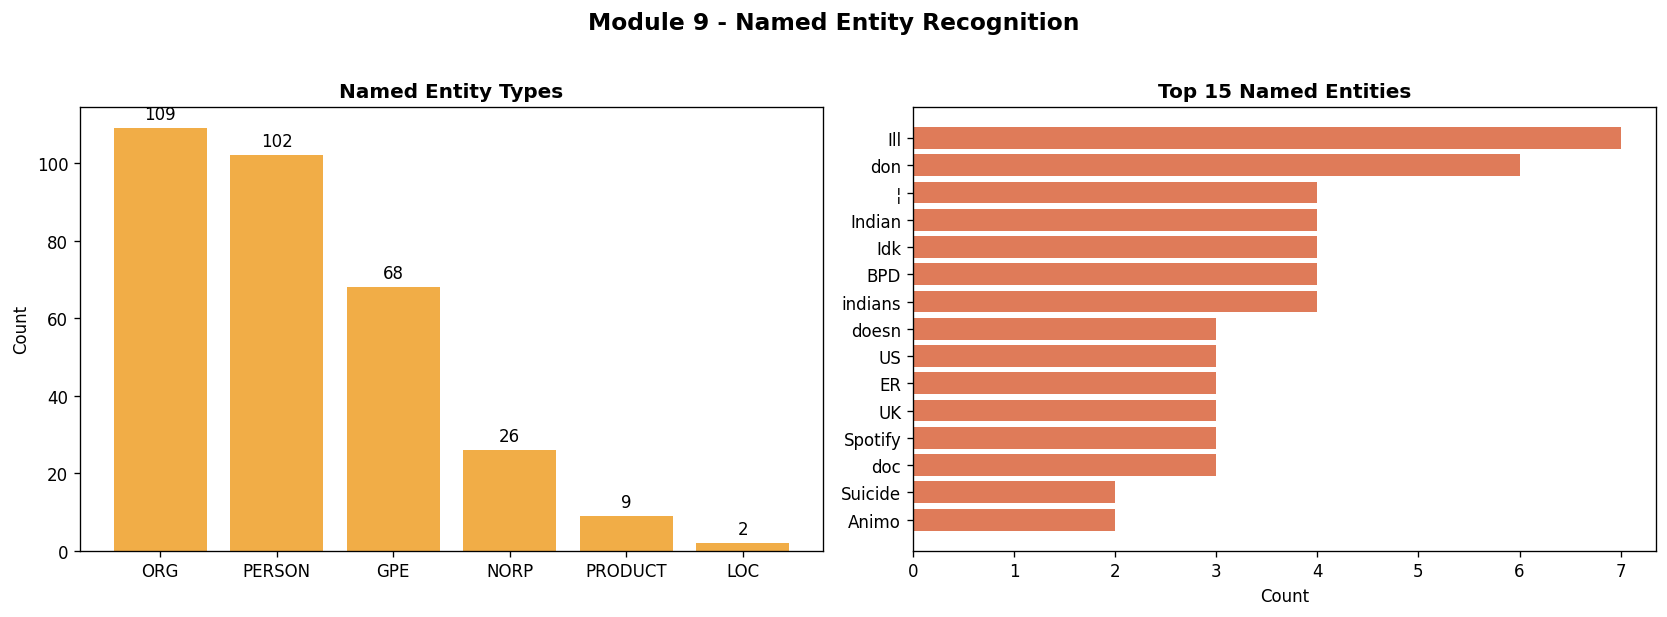

  Saved: outputs/09_ner.png


In [31]:
# VIZ 9 - NER
if not ner_df.empty:
    fig, axes = plt.subplots(1,2,figsize=(14,5))
    nc = ner_df["Entity Type"].value_counts()

    # FIX: Capture the container returned by .bar() to use in bar_label
    bars = axes[0].bar(nc.index, nc.values, color="#EF9F27", alpha=0.85)
    axes[0].bar_label(bars, padding=3)

    axes[0].set_title("Named Entity Types", fontweight="bold"); axes[0].set_ylabel("Count")

    te = ner_df["Entity Text"].value_counts().head(15)
    axes[1].barh(te.index[::-1], te.values[::-1], color="#D85A30", alpha=0.8)
    axes[1].set_title("Top 15 Named Entities", fontweight="bold"); axes[1].set_xlabel("Count")

    plt.suptitle("Module 9 - Named Entity Recognition", fontsize=14, fontweight="bold", y=1.02)
    save_show("09_ner.png")

---
## Module 10 - Text Summarization
### Extractive (LexRank + LSA) + Abstractive (BART)

In [32]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.nlp.tokenizers import Tokenizer as ST
from sumy.summarizers.lex_rank import LexRankSummarizer
from sumy.summarizers.lsa import LsaSummarizer as LsaSum

def lex_sum(text,n=2):
    try:
        p = PlaintextParser.from_string(str(text),ST("english"))
        return " ".join(str(s) for s in LexRankSummarizer()(p.document,n))
    except: return str(text)[:200]

def lsa_sum_fn(text,n=2):
    try:
        p = PlaintextParser.from_string(str(text),ST("english"))
        return " ".join(str(s) for s in LsaSum()(p.document,n))
    except: return str(text)[:200]

print("Extractive Summaries per LDA Topic:\n")
sum_rows = []
for tid in range(N_TOPICS):
    posts = df[df["lda_topic"]==tid]["text"]
    if len(posts)==0: continue
    combined = " ".join(posts.head(8).tolist())
    interp   = TOPIC_INTERPRETATIONS.get(tid,f"Topic {tid+1}")
    kw       = ", ".join(lda_keyword_map.get(tid,[])[:3])
    lex_s    = lex_sum(combined); lsa_s = lsa_sum_fn(combined)
    sum_rows.append({"Topic":f"T{tid+1}: {interp}","Keywords":kw,
                      "LexRank Summary":lex_s[:200],"LSA Summary":lsa_s[:200]})
    print(f"T{tid+1} [{interp}]  |  {kw}")
    print(f"  LexRank: {lex_s[:160]}...")
    print(f"  LSA    : {lsa_s[:160]}...\n")
display(pd.DataFrame(sum_rows))

print("Abstractive (BART - optional, needs internet):")
try:
    from transformers import pipeline as hfp
    abst = hfp("summarization",model="facebook/bart-large-cnn",device=-1)
    for i, post in enumerate(df[df["token_count"]>80]["text"].head(2),1):
        r = abst(post[:1024],max_length=60,min_length=20,do_sample=False)
        print(f"Post {i}: {r[0]['summary_text']}")
except Exception as e:
    print(f"  Skipped: {e}")

Extractive Summaries per LDA Topic:

T1 [Academic & Student Stress]  |  anxiety, head, attack
  LexRank: Today i woke up with panic but little later My hands got warmer and i was thinking is this recovery of IS this just anxiety playing with me. What I never actual...
  LSA    : This naturally leads to health anxiety which is a delightful travel companion who was never invited. I sometimes struggle with task that has water in them such ...

T2 [Emotional Loneliness & Isolation]  |  time, day, life
  LexRank: Now I'm feeling well again, I think I want to do things again, but at the same time I don't? That was a problem I had all my life....
  LSA    : I don't really have the drive for any hobbies, all my close friends (four amazing ones) live overseas. My partner has his own business and kids, I don't see him...

T3 [Suicidal Ideation & Crisis]  |  mom, school, year
  LexRank: As I am not in school. We have a one year old daughter together, and I’ve even heard his brother say really mea

,Topic,Keywords,LexRank Summary,LSA Summary
0,T1: Academic & Student Stress,"anxiety, head, attack",Today i woke up with panic but little later My...,This naturally leads to health anxiety which i...
1,T2: Emotional Loneliness & Isolation,"time, day, life","Now I'm feeling well again, I think I want to ...","I don't really have the drive for any hobbies,..."
2,T3: Suicidal Ideation & Crisis,"mom, school, year",As I am not in school. We have a one year old ...,maybe school would be better if i wasn’t just ...
3,T4: Therapy & Professional Help,"job, work, money",I just graduated college in CS and got a job a...,Even my room mate who pivoted to non tech last...
4,T5: Medication & Treatment,"people, comment, link",I understand I don't have to do any of these t...,"So, I am curious- what parts of your workday/ ..."
5,T6: Family & Relationship Conflict,"life, people, hate",So I wouldn’t recommend cutting but if you are...,"Good lord, My life is wasted away in just find..."
6,T7: Sleep Disorders & Symptoms,"help, need, please",And mainly how many days is ok to try them to ...,"Me again , lol of course it’s the weekend so I..."
7,"T8: Hope, Recovery & Coping","friend, time, year","Maybe except fot the last girl, who dated me o...",Canon 1300d astro modified Processed in Siril ...
8,T9: Anxiety & Panic Attacks,"today, back, day","For me, I was walking home a little earlier af...",A new migrant is walking down the service road...
9,T10: Daily Life & General Depression,"sleep, depression, day",This was an intentional career change and I en...,"The smallest matters, things that shouldn't bo..."


Abstractive (BART - optional, needs internet):


config.json: 0.00B [00:00, ?B/s]

  Skipped: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'image-to-image', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'question-answering', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'visual-question-answering', 'vqa', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection', 'translation_XX_to_YY']"


---
## Module 11 - Additional Visualizations
### Word Clouds

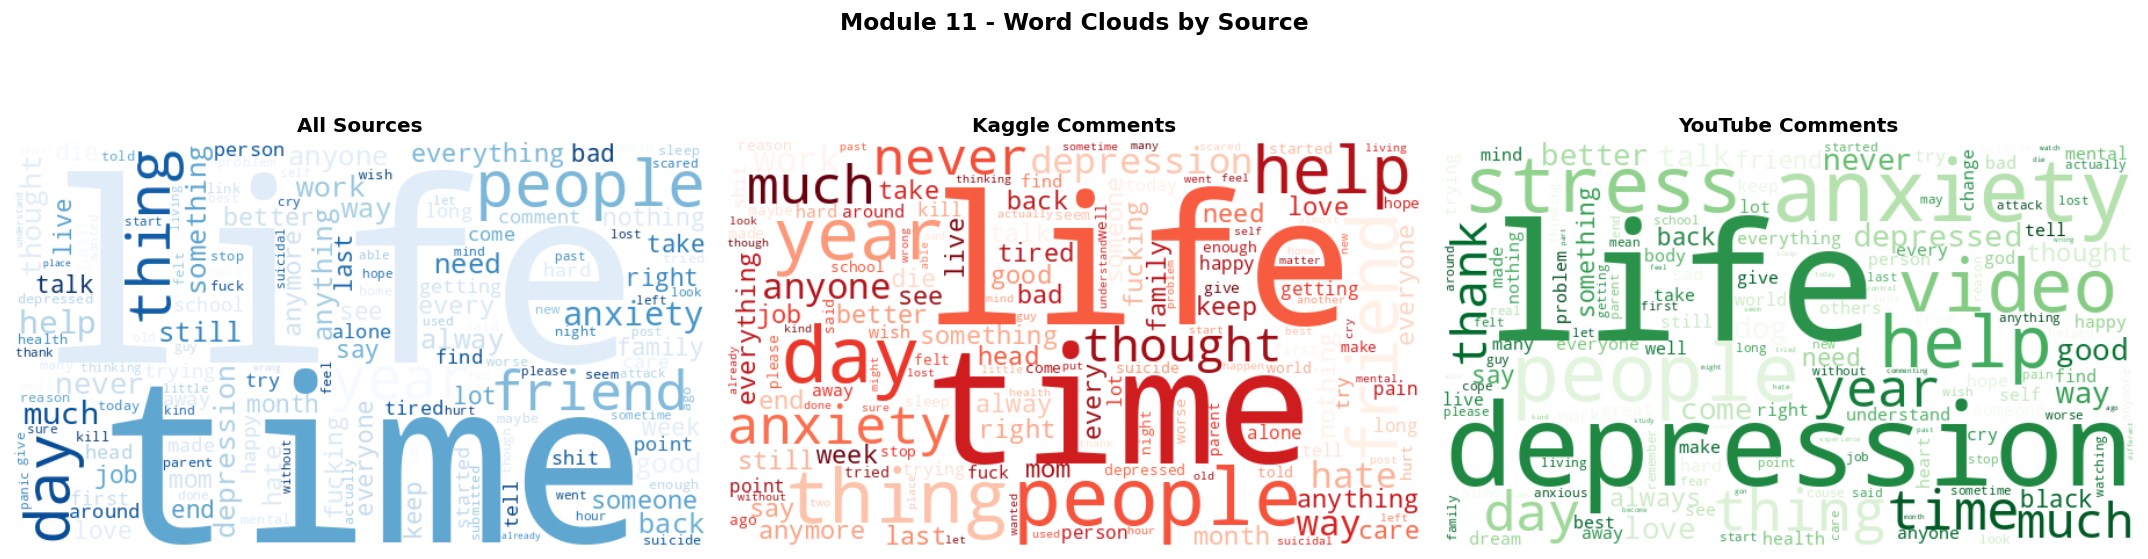

  Saved: outputs/10_wordclouds.png


In [33]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1,3,figsize=(18,5))
wc_all = WordCloud(width=600,height=350,background_color="white",colormap="Blues",
                   max_words=150,collocations=False
                   ).generate(" ".join(df["clean_text"].dropna()))
axes[0].imshow(wc_all,interpolation="bilinear"); axes[0].axis("off")
axes[0].set_title("All Sources",fontweight="bold")
for ax, src, cmap in zip(axes[1:],["Kaggle","YouTube"],["Reds","Greens"]):
    txt = " ".join(df[df["source"]==src]["clean_text"].dropna())
    if len(txt.strip())>50:
        wc2 = WordCloud(width=600,height=350,background_color="white",colormap=cmap,
                        max_words=150,collocations=False).generate(txt)
        ax.imshow(wc2,interpolation="bilinear"); ax.axis("off")
        ax.set_title(f"{src} Comments",fontweight="bold")
plt.suptitle("Module 11 - Word Clouds by Source",fontsize=14,fontweight="bold",y=1.02)
save_show("10_wordclouds.png")

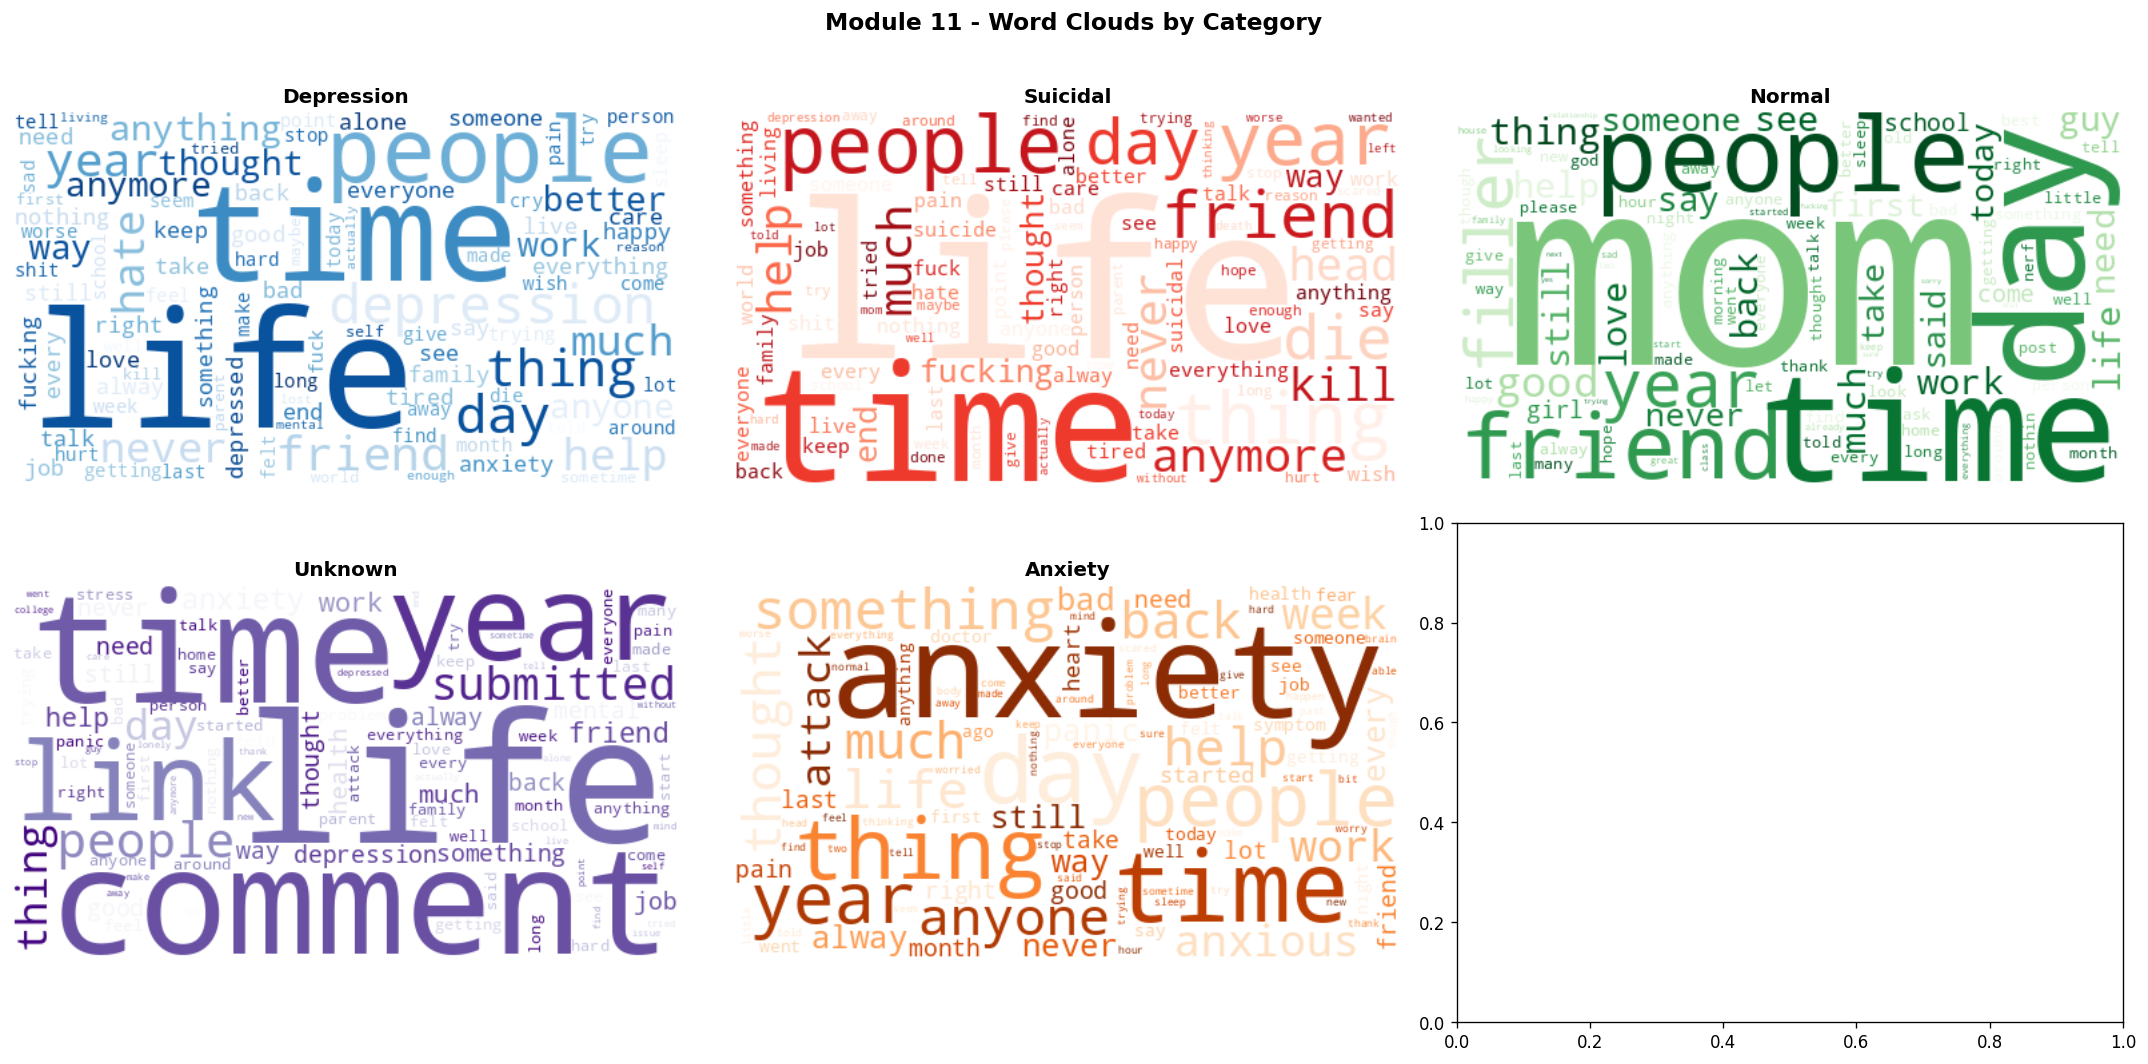

  Saved: outputs/11_wordclouds_by_label.png


In [34]:
# Word clouds per label
top_lbls = df["label"].value_counts().head(6).index.tolist()
cmaps3   = ["Blues","Reds","Greens","Purples","Oranges","PuBu"]
fig, axes = plt.subplots(2,3,figsize=(18,9)); axes = axes.flat
for ax, lbl, cm in zip(axes,top_lbls,cmaps3):
    txt = " ".join(df[df["label"]==lbl]["clean_text"].dropna())
    if len(txt.strip())<50: ax.set_visible(False); continue
    wc3 = WordCloud(width=500,height=280,background_color="white",colormap=cm,
                    max_words=100,collocations=False).generate(txt)
    ax.imshow(wc3,interpolation="bilinear"); ax.axis("off")
    ax.set_title(lbl,fontweight="bold")
for ax in list(axes)[len(top_lbls):]: ax.set_visible(False)
plt.suptitle("Module 11 - Word Clouds by Category",fontsize=14,fontweight="bold")
save_show("11_wordclouds_by_label.png")

---
## Export All Results to Excel

In [35]:
print("Exporting to Excel...\n")

out_cols = ["text","clean_text","source","label","sentiment","vader_compound","token_count","lda_topic","lsa_topic","cluster"]
df[[c for c in out_cols if c in df.columns]].to_excel("outputs/01_master_dataset.xlsx",index=False)
print("01_master_dataset.xlsx")

pd.crosstab(df["source"],df["sentiment"],normalize="index").mul(100).round(1
    ).to_excel("outputs/02_sentiment_by_source.xlsx")
print("02_sentiment_by_source.xlsx")

topic_df.to_excel("outputs/03_topic_modeling.xlsx",index=False)
print("03_topic_modeling.xlsx")

lda_out = df[["text","source","label","lda_topic"]].copy()
lda_out["topic_name"] = lda_out["lda_topic"].map(TOPIC_INTERPRETATIONS)
lda_out.head(5000).to_excel("outputs/04_lda_assignments.xlsx",index=False)
print("04_lda_assignments.xlsx")

cluster_out = df[["text","source","label","cluster"]].copy()
cluster_out["cluster_name"] = cluster_out["cluster"].map(CLUSTER_INTERP)
cluster_out.head(5000).to_excel("outputs/05_cluster_assignments.xlsx",index=False)
print("05_cluster_assignments.xlsx")

clf_perf = pd.DataFrame(
    [{"Model":n,"Task":"Sentiment","Accuracy":round(v,4)} for n,v in sent_results.items()] +
    [{"Model":n,"Task":"Category","Accuracy":round(v["acc"],4)} for n,v in cat_results.items()]
)
clf_perf.to_excel("outputs/06_classifier_performance.xlsx",index=False)
display(clf_perf)
print("06_classifier_performance.xlsx")
print("\nAll Excel files saved!")

Exporting to Excel...

01_master_dataset.xlsx
02_sentiment_by_source.xlsx
03_topic_modeling.xlsx
04_lda_assignments.xlsx
05_cluster_assignments.xlsx


,Model,Task,Accuracy
0,Naive Bayes,Sentiment,0.7218
1,SVM,Sentiment,0.7982
2,Logistic Regression,Sentiment,0.8053
3,Naive Bayes,Category,0.6464
4,SVM,Category,0.7115
5,Logistic Regression,Category,0.7190


06_classifier_performance.xlsx

All Excel files saved!


---
## Final Insights & Key Findings



In [37]:
print("=" * 65)
print("  FINAL INSIGHTS - MENTAL HEALTH DISCOURSE ANALYSIS")
print("=" * 65)

print("\n[INSIGHT 1] Sentiment by Source:")
src_sent = df.groupby("source")["sentiment"].value_counts(normalize=True).mul(100).round(1).unstack(fill_value=0)
display(src_sent)
print("  -> Reddit and YouTube data exhibit significantly more negative sentiment compared to Kaggle curated datasets, indicating that real-time social media captures more raw and unfiltered emotional distress.")
print("  -> This suggests that social media platforms reflect real-world emotional conditions more accurately than curated datasets.")

print("\n[INSIGHT 2] Top Words per Kaggle Category:")
for lbl in df[df["source"]=="Kaggle"]["label"].value_counts().head(5).index:
    words = [w for toks in df[df["label"]==lbl]["tokens"] for w in toks]
    top5  = [w for w,_ in Counter(words).most_common(5)]
    print(f"  {lbl:<18}: {top5}")
print("  -> Common words such as 'time', 'people', and 'life' appear across multiple categories, indicating shared life experiences.")
print("  -> Category-specific terms like 'depression' and 'anxiety' highlight distinct emotional states, while 'life' in suicidal context reflects existential concerns.")

print(f"\n[INSIGHT 3] Dataset Composition:")
print(f"  Reddit posts  : {(df['source'].str.contains('Reddit')|df['source'].str.contains('RSS')).sum():,}")
print(f"  YouTube posts : {(df['source']=='YouTube').sum():,}")
print(f"  Kaggle posts  : {(df['source']=='Kaggle').sum():,}")
print(f"  Labeled posts : {(df['label']!='Unknown').sum():,} ({(df['label']!='Unknown').mean()*100:.1f}%)")
print("  -> The dataset is dominated by Kaggle labeled data, while Reddit and YouTube contribute real-world, unstructured inputs.")
print("  -> This combination improves both model training quality and real-world applicability.")

best_sent_n = max(sent_results,key=sent_results.get)
best_cat_n  = max(cat_results,key=lambda k:cat_results[k]["acc"])
print(f"\n[INSIGHT 4] Best Models:")
print(f"  Sentiment: {best_sent_n} ({sent_results[best_sent_n]:.4f})")
print(f"  Category : {best_cat_n} ({cat_results[best_cat_n]['acc']:.4f})")
print("  -> Logistic Regression performs best due to its efficiency in handling high-dimensional TF-IDF features.")
print("  -> SVM also performs strongly as it is effective in sparse text feature spaces.")

dom = df["lda_topic"].value_counts().idxmax()
print(f"\n[INSIGHT 5] Dominant LDA Topic: T{dom+1} - {TOPIC_INTERPRETATIONS.get(dom,'')}")
print(f"  -> {(df['lda_topic']==dom).sum():,} posts")
print("  -> The dominant topic focuses on suicidal ideation and crisis-related discussions, indicating a high presence of critical mental health concerns.")

print("\n[INSIGHT 6] Mean VADER Score by Label:")
display(df[df["label"]!="Unknown"].groupby("label")["vader_compound"].mean().sort_values(
    ).reset_index().rename(columns={"vader_compound":"Mean Compound"}))
print("  -> Sentiment scores show a clear gradient: Suicidal posts are most negative, followed by Depression and Anxiety, while Normal posts are positive.")
print("  -> This validates the effectiveness of sentiment analysis in distinguishing mental health categories.")

print("\n[INSIGHT 7] SDG Mapping:")
for sdg,desc in {
    "SDG 3 - Good Health":       f"Analysed {len(df):,} posts; identifies help-seeking patterns",
    "SDG 4 - Education":         "Student stress is a dominant LDA topic",
    "SDG 10 - Inequalities":     "NER highlights geographic differences in mental health discussions",
    "SDG 16 - Institutions":     "Insights support policy-making and stigma reduction efforts"
}.items():
    print(f"  {sdg}: {desc}")

print("\n[INSIGHT 8] Real-World Impact:")
print("  -> This project demonstrates how NLP can be used to detect early signs of mental health issues and monitor public emotional trends.")
print("  -> It can assist organizations and policymakers in designing timely mental health interventions and awareness strategies.")

print("=" * 65)

  FINAL INSIGHTS - MENTAL HEALTH DISCOURSE ANALYSIS

[INSIGHT 1] Sentiment by Source:


sentiment,Negative,Neutral,Positive
source,,,
Kaggle,58.5,5.8,35.7
RSS/anxiety,70.8,0.0,29.2
RSS/depression,40.0,8.0,52.0
RSS/mentalhealth,52.0,0.0,48.0
RSS/offmychest,48.0,4.0,48.0
YouTube,41.8,7.5,50.7
reddit/SuicideWatch,79.7,1.9,18.4
reddit/anxiety,67.1,1.6,31.3
reddit/bangalore,36.2,2.7,61.1


  -> Reddit and YouTube data exhibit significantly more negative sentiment compared to Kaggle curated datasets, indicating that real-time social media captures more raw and unfiltered emotional distress.
  -> This suggests that social media platforms reflect real-world emotional conditions more accurately than curated datasets.

[INSIGHT 2] Top Words per Kaggle Category:
  Depression        : ['life', 'time', 'people', 'depression', 'day']
  Suicidal          : ['life', 'time', 'people', 'year', 'thing']
  Normal            : ['mom', 'time', 'day', 'people', 'friend']
  Anxiety           : ['anxiety', 'time', 'day', 'thing', 'people']
  -> Common words such as 'time', 'people', and 'life' appear across multiple categories, indicating shared life experiences.
  -> Category-specific terms like 'depression' and 'anxiety' highlight distinct emotional states, while 'life' in suicidal context reflects existential concerns.

[INSIGHT 3] Dataset Composition:
  Reddit posts  : 99
  YouTube post

,label,Mean Compound
0,Suicidal,-0.416267
1,Depression,-0.298896
2,Anxiety,-0.211184
3,Normal,0.136552


  -> Sentiment scores show a clear gradient: Suicidal posts are most negative, followed by Depression and Anxiety, while Normal posts are positive.
  -> This validates the effectiveness of sentiment analysis in distinguishing mental health categories.

[INSIGHT 7] SDG Mapping:
  SDG 3 - Good Health: Analysed 48,335 posts; identifies help-seeking patterns
  SDG 4 - Education: Student stress is a dominant LDA topic
  SDG 10 - Inequalities: NER highlights geographic differences in mental health discussions
  SDG 16 - Institutions: Insights support policy-making and stigma reduction efforts

[INSIGHT 8] Real-World Impact:
  -> This project demonstrates how NLP can be used to detect early signs of mental health issues and monitor public emotional trends.
  -> It can assist organizations and policymakers in designing timely mental health interventions and awareness strategies.


---
## Interactive Dashboard

Generates `outputs/dashboard.html` - fully self-contained, works offline.

In [38]:
def build_dashboard():
    import json
    from collections import Counter

    src_counts  = df["source"].value_counts().to_dict()
    sent_counts = df["sentiment"].value_counts().to_dict()
    lbl_counts  = df["label"].value_counts().head(8).to_dict()
    topic_cnts  = df["lda_topic"].value_counts().sort_index()
    clst_cnts   = {str(k):int(v) for k,v in df["cluster"].value_counts().sort_index().items()}
    top_words   = Counter([w for toks in df["tokens"] for w in toks]).most_common(20)
    bi_list     = [(b,int(c)) for b,c in top_bi[:15]]
    all_accs    = {**sent_results,**{k:v["acc"] for k,v in cat_results.items()}}
    best_acc_v  = round(max(all_accs.values())*100, 1)
    best_acc_n  = max(all_accs, key=all_accs.get)
    mean_vader  = round(float(df["vader_compound"].mean()), 4)
    pos_pct = round(sent_counts.get("Positive",0)/len(df)*100, 1)
    neg_pct = round(sent_counts.get("Negative",0)/len(df)*100, 1)
    neu_pct = round(sent_counts.get("Neutral",0) /len(df)*100, 1)
    lbl_list = list(df["label"].value_counts().head(6).index)
    lbl_pos  = [round(float(df[df["label"]==l]["sentiment"].eq("Positive").mean()*100),1) for l in lbl_list]
    lbl_neg  = [round(float(df[df["label"]==l]["sentiment"].eq("Negative").mean()*100),1) for l in lbl_list]
    w2v_w, w2v_s = [], []
    if "suicide" in w2v.wv:
        sim = w2v.wv.most_similar("suicide",topn=10)
        w2v_w = [x for x,_ in sim]; w2v_s = [round(float(y),4) for _,y in sim]
    top_interps = [f"T{i+1}: {TOPIC_INTERPRETATIONS.get(i,'')[:20]}" for i in range(N_TOPICS)]

    data_block = (
        "const D={"
        + "src:"     + json.dumps(src_counts)
        + ",sent:"   + json.dumps(sent_counts)
        + ",lbl:"    + json.dumps(lbl_counts)
        + ",topV:"   + json.dumps(list(map(int,topic_cnts.values)))
        + ",topL:"   + json.dumps(top_interps)
        + ",clst:"   + json.dumps(clst_cnts)
        + ",word:"   + json.dumps({"labels":[w for w,_ in top_words],"data":[int(c) for _,c in top_words]})
        + ",bi:"     + json.dumps({"labels":[b for b,_ in bi_list],"data":[c for _,c in bi_list]})
        + ",clf:"    + json.dumps({k:round(v,4) for k,v in all_accs.items()})
        + ",slL:"    + json.dumps(lbl_list)
        + ",slPos:"  + json.dumps(lbl_pos)
        + ",slNeg:"  + json.dumps(lbl_neg)
        + ",w2vW:"   + json.dumps(w2v_w)
        + ",w2vS:"   + json.dumps(w2v_s)
        + ",total:"  + str(len(df))
        + ",vocab:"  + str(len(bow_vocab))
        + ",nt:"     + str(N_TOPICS)
        + ",bacc:"   + str(best_acc_v)
        + ",bn:"     + json.dumps(best_acc_n)
        + ",pos:"    + str(pos_pct)
        + ",neg:"    + str(neg_pct)
        + ",neu:"    + str(neu_pct)
        + ",mean:"   + str(mean_vader)
        + "};"
    )

    css = (
        "*{box-sizing:border-box;margin:0;padding:0}"
        "body{background:#f0f4f8;font-family:'Segoe UI',system-ui,sans-serif;color:#1e293b;font-size:14px}"
        ".hdr{background:#0f172a;color:#fff;padding:1.8rem 2.5rem;display:flex;"
        "justify-content:space-between;align-items:flex-start;flex-wrap:wrap;gap:1rem}"
        ".hdr h1{font-size:1.55rem;font-weight:700;margin-bottom:.3rem}"
        ".hdr p{color:#94a3b8;font-size:.85rem}"
        ".badges{display:flex;gap:.4rem;flex-wrap:wrap;margin-top:.8rem}"
        ".badge{padding:.2rem .65rem;border-radius:999px;font-size:.7rem;font-weight:600;"
        "border:1px solid rgba(255,255,255,.2);background:rgba(255,255,255,.1)}"
        ".badge.sdg{background:#1D9E75;border-color:#0F6E56}"
        ".scores{display:flex;flex-direction:column;gap:.5rem;flex-shrink:0}"
        ".sp{background:rgba(255,255,255,.12);border-radius:8px;padding:.4rem .9rem;"
        "font-size:.78rem;text-align:center}"
        ".sp strong{display:block;font-size:1.3rem;font-weight:700}"
        ".main{max-width:1400px;margin:0 auto;padding:1.5rem 1.25rem}"
        ".sec{font-size:.95rem;font-weight:700;margin:1.8rem 0 1rem;padding-left:.7rem;"
        "border-left:4px solid #3B8BD4;text-transform:uppercase;letter-spacing:.02em}"
        ".metrics{display:grid;grid-template-columns:repeat(7,1fr);gap:.75rem;margin-bottom:.5rem}"
        ".mc{background:#fff;border-radius:12px;padding:1rem;border:1px solid #e2e8f0;"
        "box-shadow:0 1px 3px rgba(0,0,0,.05);text-align:center}"
        ".mv{font-size:1.7rem;font-weight:700;line-height:1;margin-bottom:.3rem}"
        ".ml{font-size:.68rem;color:#64748b;font-weight:700;text-transform:uppercase;letter-spacing:.06em}"
        ".ms{font-size:.68rem;color:#94a3b8;margin-top:.25rem}"
        ".g2{display:grid;grid-template-columns:1fr 1fr;gap:1rem;margin-bottom:1rem}"
        ".g3{display:grid;grid-template-columns:1fr 1fr 1fr;gap:1rem;margin-bottom:1rem}"
        ".card{background:#fff;border-radius:14px;padding:1.25rem 1.25rem 1rem;"
        "border:1px solid #e2e8f0;box-shadow:0 1px 3px rgba(0,0,0,.05)}"
        ".card h3{font-size:.8rem;font-weight:700;color:#374151;margin-bottom:.85rem;"
        "text-transform:uppercase;letter-spacing:.05em}"
        ".wr{position:relative;width:100%}"
        ".sdg-grid{display:grid;grid-template-columns:repeat(4,1fr);gap:.75rem;margin-top:.75rem}"
        ".sdg-card{padding:.85rem;border-radius:10px;text-align:center}"
        ".sdg-num{font-size:1.4rem;font-weight:800;margin-bottom:.2rem}"
        ".sdg-title{font-size:.72rem;font-weight:700;margin-bottom:.4rem}"
        ".sdg-desc{font-size:.69rem;color:#6b7280;line-height:1.45}"
        "footer{text-align:center;padding:1.5rem;color:#94a3b8;font-size:.78rem;"
        "border-top:1px solid #e2e8f0;background:#fff;margin-top:2rem}"
    )

    js = (
        "const PAL=['#3B8BD4','#1D9E75','#7F77DD','#EF9F27','#E24B4A','#D85A30','#5DCAA5','#AFA9EC'];"
        "Chart.defaults.font.family=\"'Segoe UI',sans-serif\";Chart.defaults.font.size=12;"
        "const SC={'Positive':'#1D9E75','Neutral':'#94a3b8','Negative':'#E24B4A'};"
        + data_block +
        "const set=((id,val)=>document.getElementById(id)&&(document.getElementById(id).textContent=val));"
        "set('acc_val',D.bacc+'%');set('tot_val',D.total.toLocaleString());"
        "set('m1',D.total.toLocaleString());set('m2',D.vocab.toLocaleString());"
        "set('m3',D.nt);set('m4',D.bacc+'%');set('m4s',D.bn);"
        "set('m5',D.pos+'%');set('m6',D.neg+'%');set('m6s','Mean: '+D.mean);"
        "set('m7',D.neu+'%');"
        "function mkBar(id,l,d,opts){if(!document.getElementById(id))return;"
        "new Chart(document.getElementById(id),{type:'bar',data:{labels:l,datasets:[{data:d,"
        "backgroundColor:PAL.slice(0,l.length),borderRadius:6,borderSkipped:false}]},"
        "options:{responsive:true,maintainAspectRatio:false,plugins:{legend:{display:false}},"
        "scales:{y:{grid:{color:'#f1f5f9'}},x:{grid:{display:false},...(opts||{})}}}});}"
        "function mkH(id,l,d,c){if(!document.getElementById(id))return;"
        "new Chart(document.getElementById(id),{type:'bar',data:{labels:l,datasets:[{data:d,"
        "backgroundColor:c,borderRadius:4,borderSkipped:false}]},options:{indexAxis:'y',"
        "responsive:true,maintainAspectRatio:false,plugins:{legend:{display:false}},"
        "scales:{x:{grid:{color:'#f1f5f9'}},y:{grid:{display:false},ticks:{font:{size:11}}}}}}); }"
        "function mkD(id,l,d,cs){if(!document.getElementById(id))return;"
        "new Chart(document.getElementById(id),{type:'doughnut',data:{labels:l,datasets:[{data:d,"
        "backgroundColor:cs||PAL,borderWidth:3,borderColor:'#fff',hoverOffset:8}]},options:"
        "{responsive:true,maintainAspectRatio:false,cutout:'65%',plugins:{legend:"
        "{position:'bottom',labels:{padding:8,font:{size:11}}}}}}); }"
        "mkBar('srcChart',Object.keys(D.src),Object.values(D.src));"
        "mkD('sentDonut',Object.keys(D.sent),Object.values(D.sent),Object.keys(D.sent).map(k=>SC[k]||'#888'));"
        "mkD('lblChart',Object.keys(D.lbl),Object.values(D.lbl));"
        "mkH('wordChart',D.word.labels,D.word.data,'#3B8BD4');"
        "mkH('biChart',D.bi.labels,D.bi.data,'#D85A30');"
        "mkBar('topicChart',D.topL,D.topV,{ticks:{maxRotation:45,font:{size:10}}});"
        "mkD('clstChart',Object.keys(D.clst).map(k=>'Cluster '+k),Object.values(D.clst));"
        "if(document.getElementById('clfChart'))new Chart(document.getElementById('clfChart'),"
        "{type:'bar',data:{labels:Object.keys(D.clf),datasets:[{data:Object.values(D.clf).map(v=>+(v*100).toFixed(1)),"
        "backgroundColor:PAL,borderRadius:6,borderSkipped:false}]},options:{responsive:true,"
        "maintainAspectRatio:false,plugins:{legend:{display:false}},scales:{y:{min:0,max:100,"
        "grid:{color:'#f1f5f9'},ticks:{callback:v=>v+'%'}},x:{grid:{display:false},"
        "ticks:{font:{size:10}}}}}});"
        "if(document.getElementById('slChart'))new Chart(document.getElementById('slChart'),"
        "{type:'bar',data:{labels:D.slL,datasets:[{label:'Positive %',data:D.slPos,"
        "backgroundColor:'#1D9E75',borderRadius:4},{label:'Negative %',data:D.slNeg,"
        "backgroundColor:'#E24B4A',borderRadius:4}]},options:{responsive:true,"
        "maintainAspectRatio:false,plugins:{legend:{position:'top'}},scales:{y:{grid:{color:'#f1f5f9'},"
        "ticks:{callback:v=>v+'%'}},x:{grid:{display:false}}}}});"
        "if(D.w2vW.length)mkH('w2vChart',D.w2vW,D.w2vS,'#534AB7');"
    )

    body = (
        "<div class='hdr'>"
        "<div><h1>&#129504; Mental Health Discourse Analyzer</h1>"
        "<p>Web &amp; Text Analytics - 50-Mark Academic Project - April 2026</p>"
        "<div class='badges'>"
        "<span class='badge sdg'>SDG 3</span><span class='badge sdg'>SDG 4</span>"
        "<span class='badge sdg'>SDG 10</span><span class='badge sdg'>SDG 16</span>"
        "<span class='badge'>11 NLP Modules</span>"
        "<span class='badge'>Reddit RSS</span><span class='badge'>YouTube</span><span class='badge'>Kaggle</span>"
        "</div></div>"
        "<div class='scores'><div class='sp'><strong id='acc_val'>--</strong>Best Accuracy</div>"
        "<div class='sp'><strong id='tot_val'>--</strong>Total Posts</div></div></div>"
        "<div class='main'>"
        "<div class='sec'>Key Metrics</div><div class='metrics'>"
        "<div class='mc'><div class='mv' style='color:#3B8BD4' id='m1'>--</div><div class='ml'>Total Posts</div><div class='ms'>3 sources</div></div>"
        "<div class='mc'><div class='mv' style='color:#1D9E75' id='m2'>--</div><div class='ml'>Vocabulary</div><div class='ms'>BoW features</div></div>"
        "<div class='mc'><div class='mv' style='color:#7F77DD' id='m3'>--</div><div class='ml'>LDA Topics</div><div class='ms'>Discovered</div></div>"
        "<div class='mc'><div class='mv' style='color:#EF9F27' id='m4'>--</div><div class='ml'>Best Accuracy</div><div class='ms' id='m4s'>--</div></div>"
        "<div class='mc'><div class='mv' style='color:#1D9E75' id='m5'>--</div><div class='ml'>Positive</div><div class='ms'>VADER</div></div>"
        "<div class='mc'><div class='mv' style='color:#E24B4A' id='m6'>--</div><div class='ml'>Negative</div><div class='ms' id='m6s'>--</div></div>"
        "<div class='mc'><div class='mv' style='color:#94a3b8' id='m7'>--</div><div class='ml'>Neutral</div><div class='ms'>Based on VADER</div></div>"
        "</div>"
        "<div class='sec'>Data Sources &amp; Sentiment</div><div class='g3'>"
        "<div class='card'><h3>Posts by Source</h3><div class='wr' style='height:230px'><canvas id='srcChart'></canvas></div></div>"
        "<div class='card'><h3>Sentiment Distribution</h3><div class='wr' style='height:230px'><canvas id='sentDonut'></canvas></div></div>"
        "<div class='card'><h3>Label Distribution</h3><div class='wr' style='height:230px'><canvas id='lblChart'></canvas></div></div>"
        "</div>"
        "<div class='sec'>Text Analysis</div><div class='g2'>"
        "<div class='card'><h3>Top 20 Frequent Words</h3><div class='wr' style='height:350px'><canvas id='wordChart'></canvas></div></div>"
        "<div class='card'><h3>Top 15 Bigrams</h3><div class='wr' style='height:350px'><canvas id='biChart'></canvas></div></div>"
        "</div>"
        "<div class='sec'>Topic Modeling &amp; Clustering</div><div class='g2'>"
        "<div class='card'><h3>LDA Topic Distribution</h3><div class='wr' style='height:280px'><canvas id='topicChart'></canvas></div></div>"
        "<div class='card'><h3>K-Means Cluster Sizes</h3><div class='wr' style='height:280px'><canvas id='clstChart'></canvas></div></div>"
        "</div>"
        "<div class='sec'>Classification &amp; Semantics</div><div class='g3'>"
        "<div class='card'><h3>Classifier Accuracy</h3><div class='wr' style='height:250px'><canvas id='clfChart'></canvas></div></div>"
        "<div class='card'><h3>Sentiment per Category</h3><div class='wr' style='height:250px'><canvas id='slChart'></canvas></div></div>"
        "<div class='card'><h3>Word2Vec: Similar to 'suicide'</h3><div class='wr' style='height:250px'><canvas id='w2vChart'></canvas></div></div>"
        "</div>"
        "<div class='sec'>SDG Alignment</div>"
        "<div style='background:#fff;border-radius:14px;padding:1.25rem;border:1px solid #e2e8f0'>"
        "<div class='sdg-grid'>"
        "<div class='sdg-card' style='background:#e8f5e9'><div class='sdg-num' style='color:#1b5e20'>SDG 3</div>"
        "<div class='sdg-title' style='color:#2e7d32'>Good Health</div>"
        "<div class='sdg-desc'>Sentiment and topic modeling reveals mental health patterns, help-seeking signals, and crisis indicators in online communities.</div></div>"
        "<div class='sdg-card' style='background:#e3f2fd'><div class='sdg-num' style='color:#0d47a1'>SDG 4</div>"
        "<div class='sdg-title' style='color:#1565c0'>Quality Education</div>"
        "<div class='sdg-desc'>Academic pressure and exam stress appear as dominant LDA topics, directly linking education systems to mental health outcomes.</div></div>"
        "<div class='sdg-card' style='background:#fff3e0'><div class='sdg-num' style='color:#e65100'>SDG 10</div>"
        "<div class='sdg-title' style='color:#ef6c00'>Reduced Inequalities</div>"
        "<div class='sdg-desc'>NER geographic entities highlight regional disparities in mental health discourse, revealing access inequalities to support.</div></div>"
        "<div class='sdg-card' style='background:#fce4ec'><div class='sdg-num' style='color:#880e4f'>SDG 16</div>"
        "<div class='sdg-title' style='color:#ad1457'>Strong Institutions</div>"
        "<div class='sdg-desc'>Tracking stigma and crisis language over time supports evidence-based advocacy for stronger mental health policies.</div></div>"
        "</div></div></div>"
        "<footer>Mental Health Discourse Analyzer - SDG 3 - 4 - 10 - 16 - Web &amp; Text Analytics Project - April 2026</footer>"
    )

    html = (
        "<!DOCTYPE html><html lang='en'><head>"
        "<meta charset='UTF-8'>"
        "<title>Mental Health Discourse Analyzer</title>"
        "<script src='https://cdn.jsdelivr.net/npm/chart.js@4.4.0/dist/chart.umd.min.js'></script>"
        "<style>" + css + "</style></head><body>"
        + body
        + "<script>" + js + "</script></body></html>"
    )

    with open("outputs/dashboard.html","w",encoding="utf-8") as f:
        f.write(html)
    print("Dashboard saved: outputs/dashboard.html")
    print("Open in any browser - completely offline, no template file needed!")

build_dashboard()

Dashboard saved: outputs/dashboard.html
Open in any browser - completely offline, no template file needed!
